# Stitched waterfalls: the 29_n15 **7-27-26** full scan — FBZ / Optimal / PFBZ

This is [`waterfall_stitched_29_n15_3seg.ipynb`](waterfall_stitched_29_n15_3seg.ipynb) generalised
from **one condition** (Optimal) to **all three** conditions of the 7/27 acquisition:

`data/focusing_images/7-27-26/29_n15/{FBZ, Optimal, PFBZ}/`

Every condition is scanned in overlapping segments whose `positions.csv` is *local* (each restarts at
0.0), so a segment's true global $z$ is `local_z + offset`. The layout:

| condition | segments | charges |
|---|---|---|
| **FBZ**     | `0mm-25mm`, `20mm-45mm`, `40mm-65mm`               | $\ell = 0\ldots5$ |
| **Optimal** | `0mm-25mm`, `20mm-45mm`, `40mm-65mm`, `60mm-85mm`  | $\ell = 0\ldots5$; **`60mm-85mm` only $\ell=1$** |
| **PFBZ**    | `0mm-25mm`, `20mm-45mm`, `40mm-65mm`               | $\ell = 0\ldots5$ |

**Everything else is the same as the 3-seg notebook.** The pipeline, per condition, per $\ell$:

1. Process each segment independently with the base pipeline (centroid tracking → transverse slice →
   per-segment waterfall) on its *local* $z$, plus a per-frame beam-width trace.
2. Place segment $k$ at `local_z + STARTS_MM[cond][ell][seg]` (absolute global starts, hand-set).
3. **Stitch** onto one common global-$z$ grid (linear interpolation in $z$), blending overlapping
   segments — *crossfade*, *average*, or *hardcut* — handling any number of seams in one pass.
4. Draw the stitched waterfalls, stitched width curves, centroid diagnostic, and a summary table.

Outputs go under `outputs/waterfalls_stitched_full/<condition>/`.

> **Data note.** In `Optimal/0mm-25mm/l=0/` the TIFFs are named `29_n15_l5_*.tif` — a stale filename
> prefix from acquisition (same quirk the 3-seg notebook documented). The loader keys off the
> **folder**, not the filename, so the folder name is authoritative.

In [24]:
from __future__ import annotations

import re
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


def find_repo_root(start: Path | None = None) -> Path:
    '''Walk up to the directory holding pyproject.toml (see the base notebook).'''
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(f"no pyproject.toml at or above {here}")


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "focusing_images"
SCAN_ROOT = DATA_ROOT / "7-27-26" / "29_n15"
OUT_ROOT = REPO_ROOT / "outputs" / "waterfalls_stitched_full"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"repo root : {REPO_ROOT}")
print(f"scan root : {SCAN_ROOT}")
print(f"figures   : {OUT_ROOT}")
assert SCAN_ROOT.is_dir(), f"missing {SCAN_ROOT}"


repo root : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing
scan root : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing/data/focusing_images/7-27-26/29_n15
figures   : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing/outputs/waterfalls_stitched_full


## Tunables

`CONDITIONS` is an **ordered** mapping — one entry per condition, each listing its segment folders in
chain order with the nominal global start (mm) taken from the folder name. Add / remove entries and
the whole notebook follows; nothing hard-codes a count.

The slicing / centroid knobs are copied verbatim from the base notebook so the analyses stay directly
comparable.

In [25]:
RUN = "29_n15_7-27-26"

# Segment folder name -> nominal global start (mm), parsed from the "AmmBmm" folder name.
def nominal_start(folder_name: str) -> float:
    m = re.match(r"(\d+)mm-(\d+)mm", folder_name)
    if not m:
        raise ValueError(f"cannot parse a nominal start from folder {folder_name!r}")
    return float(m.group(1))

# Ordered: condition -> segment folders in chain order. Each segment is aligned against the
# ones already placed to its left. Charges present are discovered per segment (some segments
# lack some ells, e.g. Optimal/60mm-85mm is l=1 only).
CONDITION_SEGMENTS = {
    "FBZ":     ["0mm-25mm", "20mm-45mm", "40mm-65mm"],
    "Optimal": ["0mm-25mm", "20mm-45mm", "40mm-65mm"],#, "60mm-85mm"],
    "PFBZ":    ["0mm-25mm", "20mm-45mm", "40mm-65mm"],
}

ELLS = [0, 1, 2, 3, 4, 5]            # charges to attempt; missing (segment, ell) pairs are skipped

STEP_MM = 0.5                        # stage step; also the fallback if a positions.csv is odd

# --- slicing (verbatim from waterfall_plot.ipynb) -------------------------
SLICE_AXIS = "x"
N_LINES_AVG = 1
TRACK_CENTRE_PER_FRAME = True
CENTER_TRANSVERSE = True
CROP_HALF_WIDTH = 200

# --- centroid finding (verbatim) ------------------------------------------
BG_BORDER = 50
THRESH_FRAC = 0.10
WINDOW_RADIUS = 200
# --------------------------------------------------------------------------

if SLICE_AXIS not in ("x", "y"):
    raise ValueError(f"SLICE_AXIS must be 'x' or 'y', got {SLICE_AXIS!r}")

# Discover which (condition, segment, ell) folders actually exist.
for cond, seg_labels in CONDITION_SEGMENTS.items():
    cdir = SCAN_ROOT / cond
    assert cdir.is_dir(), f"missing condition folder {cdir}"
    for seg in seg_labels:
        assert (cdir / seg).is_dir(), f"missing segment folder {cdir / seg}"

print(f"slicing along {SLICE_AXIS}")
for cond, seg_labels in CONDITION_SEGMENTS.items():
    print(f"{cond:>8}: {' -> '.join(seg_labels)}")

slicing along x
     FBZ: 0mm-25mm -> 20mm-45mm -> 40mm-65mm
 Optimal: 0mm-25mm -> 20mm-45mm -> 40mm-65mm
    PFBZ: 0mm-25mm -> 20mm-45mm -> 40mm-65mm


## Frame loading, background, centroid — unchanged from the base notebook

Identical helpers: frames ordered by the trailing `_NNNN` index, loaded as `float32`;
background = median of a border strip; centroid = background-subtracted, thresholded intensity
centroid refined within a window. A `Segment` here is one `l=<n>` folder of one segment of one
condition.

In [26]:
INDEX_RE = re.compile(r"_(\d+)\.tif$", re.IGNORECASE)


@dataclass(frozen=True)
class Segment:
    '''One `l=<n>` folder within one segment of one condition.'''

    cond: str
    seg: str          # folder name, e.g. "0mm-25mm"
    ell: int
    directory: Path
    nominal_start_mm: float


def frame_index(path: Path) -> int:
    m = INDEX_RE.search(path.name)
    if m is None:
        raise ValueError(f"cannot parse a frame index from {path.name}")
    return int(m.group(1))


def frame_paths(directory: Path) -> list[Path]:
    tifs = [p for p in directory.glob("*.tif") if not p.name.startswith(".")]
    return sorted(tifs, key=frame_index)


def load_local_positions(directory: Path, paths: list[Path]) -> np.ndarray:
    '''Local z (mm) from positions.csv, falling back to index*STEP_MM if it is unusable.'''
    csv = directory / "positions.csv"
    if csv.is_file():
        table = pd.read_csv(csv)
        by_name = dict(zip(table["image"], table["position_mm"]))
        if all(p.name in by_name for p in paths):
            return np.array([float(by_name[p.name]) for p in paths])
        print(f"  ! {directory.parent.name}/{directory.name}: positions.csv does not name every "
              f"frame — inferring local z = index * {STEP_MM} mm")
    else:
        print(f"  ! {directory.parent.name}/{directory.name}: no positions.csv — "
              f"inferring local z = index * {STEP_MM} mm")
    return np.array([frame_index(p) * STEP_MM for p in paths])


def load_frames(paths: list[Path]) -> np.ndarray:
    first = np.asarray(Image.open(paths[0]), dtype=np.float32)
    frames = np.empty((len(paths), *first.shape), dtype=np.float32)
    frames[0] = first
    for i, path in enumerate(paths[1:], start=1):
        frame = np.asarray(Image.open(path), dtype=np.float32)
        if frame.shape != first.shape:
            raise ValueError(f"{path.name} is {frame.shape}, expected {first.shape}")
        frames[i] = frame
    return frames


def background_level(frame: np.ndarray, border: int = BG_BORDER) -> float:
    edges = np.concatenate([
        frame[:border, :].ravel(), frame[-border:, :].ravel(),
        frame[:, :border].ravel(), frame[:, -border:].ravel(),
    ])
    return float(np.median(edges))


def _centroid(weights: np.ndarray) -> tuple[float, float]:
    total = weights.sum()
    if total <= 0:
        raise ValueError("no signal above threshold")
    rows = np.arange(weights.shape[0])[:, None]
    cols = np.arange(weights.shape[1])[None, :]
    return float((weights * rows).sum() / total), float((weights * cols).sum() / total)


def find_centroid(frame: np.ndarray) -> tuple[float, float, float]:
    signal = np.clip(frame - background_level(frame), 0, None)
    weights = np.where(signal >= THRESH_FRAC * signal.max(), signal, 0.0)
    cy, cx = _centroid(weights)
    if WINDOW_RADIUS is not None:
        r0 = max(int(round(cy)) - WINDOW_RADIUS, 0)
        c0 = max(int(round(cx)) - WINDOW_RADIUS, 0)
        window = weights[r0:r0 + 2 * WINDOW_RADIUS, c0:c0 + 2 * WINDOW_RADIUS]
        dy, dx = _centroid(window)
        cy, cx = r0 + dy, c0 + dx
    # brightness weight: bright, well-defined in-focus frames dominate the line fit
    return cy, cx, float(signal.max())

## Process one segment into a waterfall + a registration feature

`process_segment` is the base notebook's `process_dataset`, extended to also return a per-frame
**beam-width** trace used for alignment: the intensity-weighted transverse **RMS radius** about the
centre of each already-centred, background-subtracted slice.

In [27]:
@dataclass
class SegWaterfall:
    '''One segment of one ell: its waterfall on *local* z, plus registration features.'''

    cond: str
    seg: str
    ell: int
    nominal_start_mm: float
    waterfall: np.ndarray     # (n_z, n_s), NOT yet peak-normalised (raw, bg-subtracted)
    s_px: np.ndarray          # (n_s,) transverse coord about the centre
    z_local: np.ndarray       # (n_z,) local z (mm)
    centroid_y: np.ndarray          # FITTED straight-line centroid actually used
    centroid_x: np.ndarray
    centroid_y_raw: np.ndarray      # raw per-frame centroid, kept for diagnostics
    centroid_x_raw: np.ndarray
    centroid_w: np.ndarray          # per-frame brightness weight used in the fit
    width_px: np.ndarray      # (n_z,) transverse RMS radius per frame
    onaxis: np.ndarray        # (n_z,) central-column intensity per frame


def _rms_width(profile: np.ndarray, s_px: np.ndarray) -> float:
    w = np.clip(profile, 0, None)
    total = w.sum()
    if total <= 0:
        return np.nan
    mean = (w * s_px).sum() / total
    return float(np.sqrt((w * (s_px - mean) ** 2).sum() / total))


def segment_raw_centroids(segment: Segment):
    """Pass 1: load a segment's frames and return (z_local, centroid_y,
    centroid_x, weight) -- the RAW per-frame centroid and brightness, before the
    shared straight-line fit."""
    paths = frame_paths(segment.directory)
    if not paths:
        raise FileNotFoundError(f"no TIFFs in {segment.directory}")
    z_local = load_local_positions(segment.directory, paths)
    frames = load_frames(paths)
    cen = np.array([find_centroid(f) for f in frames])   # (n, 3): row, col, brightness
    return z_local, cen[:, 0], cen[:, 1], cen[:, 2]


def process_segment(segment: Segment, centroid_y: np.ndarray, centroid_x: np.ndarray,
                    centroid_y_raw: np.ndarray, centroid_x_raw: np.ndarray,
                    centroid_w: np.ndarray) -> SegWaterfall:
    """Pass 2: build one segment's waterfall on the supplied FITTED straight-line
    centroid (no per-frame wobble).  Frames are reloaded here (released after the
    raw-centroid pass) so peak memory stays at a single segment."""
    paths = frame_paths(segment.directory)
    z_local = load_local_positions(segment.directory, paths)
    frames = load_frames(paths)

    if SLICE_AXIS == "x":
        cuts, centre_along, centre_across = frames, centroid_y, centroid_x
    else:
        cuts, centre_along, centre_across = frames.transpose(0, 2, 1), centroid_x, centroid_y
    n_lines, length = cuts.shape[1], cuts.shape[2]

    half = N_LINES_AVG // 2
    fixed_line = int(round(centre_along.mean()))
    background = float(np.median([background_level(f) for f in frames]))

    slices = []
    for plane, c_along, c_across in zip(cuts, centre_along, centre_across):
        line = int(round(c_along)) if TRACK_CENTRE_PER_FRAME else fixed_line
        lo = int(np.clip(line - half, 0, n_lines - N_LINES_AVG))
        cut = plane[lo:lo + N_LINES_AVG].mean(axis=0)
        if CENTER_TRANSVERSE:
            cut = np.roll(cut, length // 2 - int(round(c_across)))
        slices.append(cut)

    waterfall = np.clip(np.stack(slices) - background, 0, None)  # raw, not peak-normalised
    del cuts, frames

    s_px = np.arange(length) - (length // 2 if CENTER_TRANSVERSE else 0)
    if CROP_HALF_WIDTH is not None:
        keep = np.abs(s_px) <= CROP_HALF_WIDTH
        waterfall, s_px = waterfall[:, keep], s_px[keep]

    width_px = np.array([_rms_width(row, s_px) for row in waterfall])
    centre_idx = int(np.argmin(np.abs(s_px)))
    onaxis = waterfall[:, centre_idx].astype(float)

    return SegWaterfall(
        cond=segment.cond, seg=segment.seg, ell=segment.ell,
        nominal_start_mm=segment.nominal_start_mm,
        waterfall=waterfall, s_px=s_px, z_local=z_local,
        centroid_y=centroid_y, centroid_x=centroid_x,
        centroid_y_raw=centroid_y_raw, centroid_x_raw=centroid_x_raw, centroid_w=centroid_w,
        width_px=width_px, onaxis=onaxis,
    )

## Process every segment of every condition, for every $\ell$

A missing `l=<n>` folder inside a segment is simply skipped (Optimal's `60mm-85mm` only has $\ell=1$),
so each $\ell$ ends up with exactly the segments that exist for it. This is the slow cell — a few
minutes — 60-odd folders of 51 frames.

In [28]:
# data[cond][ell][seg] = SegWaterfall
# Straight-line centroid, fit PER CONDITION: all of a condition's segments share
# ONE slope (the geometric beam walk-off per mm), each segment keeps its own
# offset; then build each segment on that smooth line instead of the wobbling
# per-frame centroid.
#   pass 1: raw per-frame centroid + brightness for every (ell, seg) of a condition
#   fit:    one shared-slope line per condition for both centroid axes
#   pass 2: rebuild each segment on its fitted line (frames reloaded, so peak
#           memory stays at a single segment).
from centroid_lines import fit_centroid_lines

data: dict[str, dict[int, dict[str, SegWaterfall]]] = {}

for cond, seg_labels in CONDITION_SEGMENTS.items():
    cdir = SCAN_ROOT / cond

    raw_sections: dict[tuple[int, str], dict] = {}
    segment_objs: dict[tuple[int, str], Segment] = {}
    for ell in ELLS:
        for seg in seg_labels:
            directory = cdir / seg / f"l={ell}"
            if not directory.is_dir():
                continue
            segment = Segment(cond, seg, ell, directory, nominal_start(seg))
            z_local, cy, cx, w = segment_raw_centroids(segment)
            raw_sections[(ell, seg)] = dict(z=z_local, cy=cy, cx=cx, w=w)
            segment_objs[(ell, seg)] = segment
    if not raw_sections:
        data[cond] = {}
        continue

    lines, (slope_y, slope_x) = fit_centroid_lines(raw_sections)

    data[cond] = {ell: {} for ell in ELLS}
    for (ell, seg), segment in segment_objs.items():
        r = raw_sections[(ell, seg)]
        cy_fit, cx_fit = lines[(ell, seg)]
        data[cond][ell][seg] = process_segment(
            segment, cy_fit, cx_fit, r["cy"], r["cx"], r["w"])
    data[cond] = {ell: segs for ell, segs in data[cond].items() if segs}
    print(f"{cond:>8}: centroid slope (y, x) = ({slope_y:+.3f}, {slope_x:+.3f}) px/mm; "
          + ", ".join(f"l{ell}:{len(data[cond][ell])}" for ell in data[cond]))

print("\ndone. per-condition (ell: n_segments):")
for cond in CONDITION_SEGMENTS:
    if data.get(cond):
        print(f"  {cond:>8}: " + ", ".join(f"l{ell}:{len(data[cond][ell])}" for ell in data[cond]))


     FBZ  l=0  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
     FBZ  l=1  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
     FBZ  l=2  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
     FBZ  l=3  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
     FBZ  l=4  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
     FBZ  l=5  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
 Optimal  l=0  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
 Optimal  l=1  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
 Optimal  l=2  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
 Optimal  l=3  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
 Optimal  l=4  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
 Optimal  l=5  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
    PFBZ  l=0  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
    PFBZ  l=1  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
    PFBZ  l=2  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
    PFBZ  l=3  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']
    PFBZ  l=4  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm

## Set each segment's global start — edit the offsets **file** `waterfall_offsets.csv`

Segment $k$'s global $z$ is `local_z + start_mm[cond][ell][seg]`. These are **absolute** global
starts, so each segment is tuned independently — nudging one does not move the next. The reference
(first) segment of every condition is pinned at 0 by definition.

**The offsets live in an editable file**, `waterfall_offsets.csv`, next to this notebook — one row per
`(condition, ell, segment)` stitch, with a `start_mm` column you edit. Workflow:

1. Run this cell once. If the file doesn't exist it's **created**, seeded with the 3-seg defaults
   (nominal + ~4 mm); a `nominal_start_mm` column is included for reference (read-only).
2. Open `waterfall_offsets.csv`, change the `start_mm` of any individual stitch, save.
3. **Re-run this cell and everything below** — the new offsets flow through the whole notebook.

The file is only rewritten when stitches are added/removed (so your hand-edits are never clobbered on a
normal edit-and-rerun). Use the alignment-diagnostic and seam-zoom figures below to judge each value.
$\ell=0$ is a Gaussian (no sharp width match), so its values just follow the donut consensus.

In [29]:
# Editable offsets file, one row per (condition, ell, segment). EDIT start_mm THERE, not here.
OFFSETS_FILE = REPO_ROOT / "waterfall_offsets.csv"

# Seed values by folder name (nominal + the ~4 mm correction the 3-seg notebook found), used only
# to populate the file the first time or to fill any newly appeared stitch.
DEFAULT_START = {
    "0mm-25mm": 0.0,     # reference segment, pinned at 0
    "20mm-45mm": 24.0,
    "40mm-65mm": 44.5,
    "60mm-85mm": 64.5,
}


def default_for(seg: str) -> float:
    return DEFAULT_START.get(seg, nominal_start(seg))


# Every (condition, ell, segment) that actually has data, in chain order.
needed = [(cond, ell, seg)
          for cond in CONDITION_SEGMENTS
          for ell in data[cond]
          for seg in data[cond][ell]]

# Load any offsets the user has already edited.
existing: dict[tuple[str, int, str], float] = {}
if OFFSETS_FILE.is_file():
    prev = pd.read_csv(OFFSETS_FILE)
    for _, r in prev.iterrows():
        existing[(str(r["condition"]), int(r["ell"]), str(r["segment"]))] = float(r["start_mm"])

# Merge: keep every edited value, fill missing stitches from the seed defaults.
merged = {key: existing.get(key, default_for(key[2])) for key in needed}

offsets_df = pd.DataFrame(
    [{"condition": c, "ell": e, "segment": s,
      "nominal_start_mm": nominal_start(s), "start_mm": round(float(merged[(c, e, s)]), 3)}
     for (c, e, s) in needed]
)

# (Re)write only when the set of stitches changed, so hand-edits + reruns never clobber the file.
added = [k for k in needed if k not in existing]
stale = [k for k in existing if k not in set(needed)]
if not OFFSETS_FILE.is_file():
    offsets_df.to_csv(OFFSETS_FILE, index=False)
    print(f"created {OFFSETS_FILE.name} with {len(needed)} stitches — "
          f"edit the start_mm column and re-run this cell")
elif added or stale:
    offsets_df.to_csv(OFFSETS_FILE, index=False)
    print(f"updated {OFFSETS_FILE.name}: +{len(added)} new, -{len(stale)} removed "
          f"({len(needed)} stitches total)")
else:
    print(f"loaded {len(needed)} offsets from {OFFSETS_FILE.name} (unchanged)")

# Build STARTS_MM[cond][ell][seg] from the merged table (chain order preserved).
STARTS_MM: dict[str, dict[int, dict[str, float]]] = {}
for (cond, ell, seg) in needed:
    STARTS_MM.setdefault(cond, {}).setdefault(ell, {})[seg] = float(merged[(cond, ell, seg)])

# The first segment present for each ell must be pinned at 0 (defines global z = local z).
for cond in STARTS_MM:
    for ell, starts in STARTS_MM[cond].items():
        ref = next(iter(starts))
        assert starts[ref] == 0.0, (
            f"{cond} l={ell}: reference segment {ref!r} must have start_mm = 0.0 in "
            f"{OFFSETS_FILE.name} (it defines the global-z origin)")

for cond in CONDITION_SEGMENTS:
    print(f"== {cond} ==")
    for ell in data[cond]:
        parts = [f"{seg} @ {STARTS_MM[cond][ell][seg]:6.2f}" for seg in data[cond][ell]]
        print(f"  l={ell}: " + " | ".join(parts))

loaded 54 offsets from waterfall_offsets.csv (unchanged)
== FBZ ==
  l=0: 0mm-25mm @   0.00 | 20mm-45mm @  22.50 | 40mm-65mm @  45.00
  l=1: 0mm-25mm @   0.00 | 20mm-45mm @  22.50 | 40mm-65mm @  45.50
  l=2: 0mm-25mm @   0.00 | 20mm-45mm @  24.00 | 40mm-65mm @  46.50
  l=3: 0mm-25mm @   0.00 | 20mm-45mm @  23.00 | 40mm-65mm @  45.50
  l=4: 0mm-25mm @   0.00 | 20mm-45mm @  23.00 | 40mm-65mm @  46.00
  l=5: 0mm-25mm @   0.00 | 20mm-45mm @  23.00 | 40mm-65mm @  46.00
== Optimal ==
  l=0: 0mm-25mm @   0.00 | 20mm-45mm @  24.00 | 40mm-65mm @  44.50
  l=1: 0mm-25mm @   0.00 | 20mm-45mm @  24.50 | 40mm-65mm @  45.00
  l=2: 0mm-25mm @   0.00 | 20mm-45mm @  24.00 | 40mm-65mm @  43.50
  l=3: 0mm-25mm @   0.00 | 20mm-45mm @  24.00 | 40mm-65mm @  44.00
  l=4: 0mm-25mm @   0.00 | 20mm-45mm @  24.00 | 40mm-65mm @  44.50
  l=5: 0mm-25mm @   0.00 | 20mm-45mm @  24.50 | 40mm-65mm @  44.50
== PFBZ ==
  l=0: 0mm-25mm @   0.00 | 20mm-45mm @  21.00 | 40mm-65mm @  43.50
  l=1: 0mm-25mm @   0.00 | 20mm-45mm 

### Helpers shared by the per-condition figures

`seg_order(cond, ell)` is the chain order of the segments that exist for that $\ell$; `global_z`
places a segment's frames on the global axis; `seams(cond, ell)` are the consecutive pairs.

In [30]:
def seg_order(cond: str, ell: int) -> list[str]:
    '''Segments present for this (condition, ell), in chain order.'''
    return [s for s in CONDITION_SEGMENTS[cond] if s in data[cond][ell]]


def global_z(sw: SegWaterfall, ell: int) -> np.ndarray:
    '''A segment's frames on the global z axis, given the hand-set starts.'''
    return sw.z_local + STARTS_MM[sw.cond][ell][sw.seg]


def seams(cond: str, ell: int) -> list[tuple[str, str]]:
    order = seg_order(cond, ell)
    return list(zip(order[:-1], order[1:]))


def cond_out(cond: str) -> Path:
    d = OUT_ROOT / cond
    d.mkdir(parents=True, exist_ok=True)
    return d

### Check the offsets: do the width curves line up?

One panel per $\ell$ (per condition): every segment's beam-width trace on global $z$ at its hand-set
start (solid, coloured), plus — faint grey — each non-reference segment at its **nominal** start.
Vertical dashed lines mark the seams. A good set of starts has neighbouring curves lying on top of
each other through each shared band. No searching happens here — this only *shows* the starts you
set.

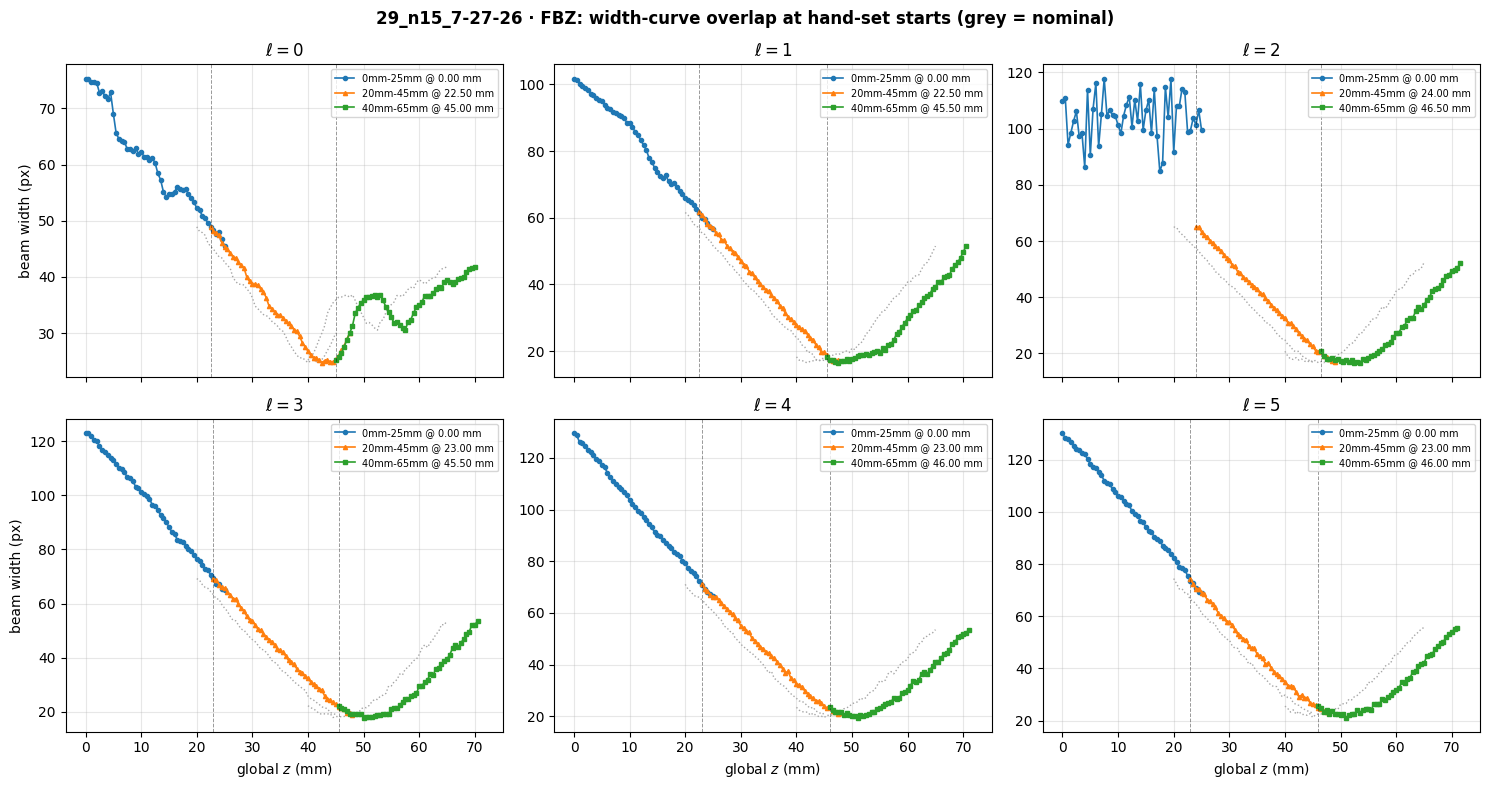

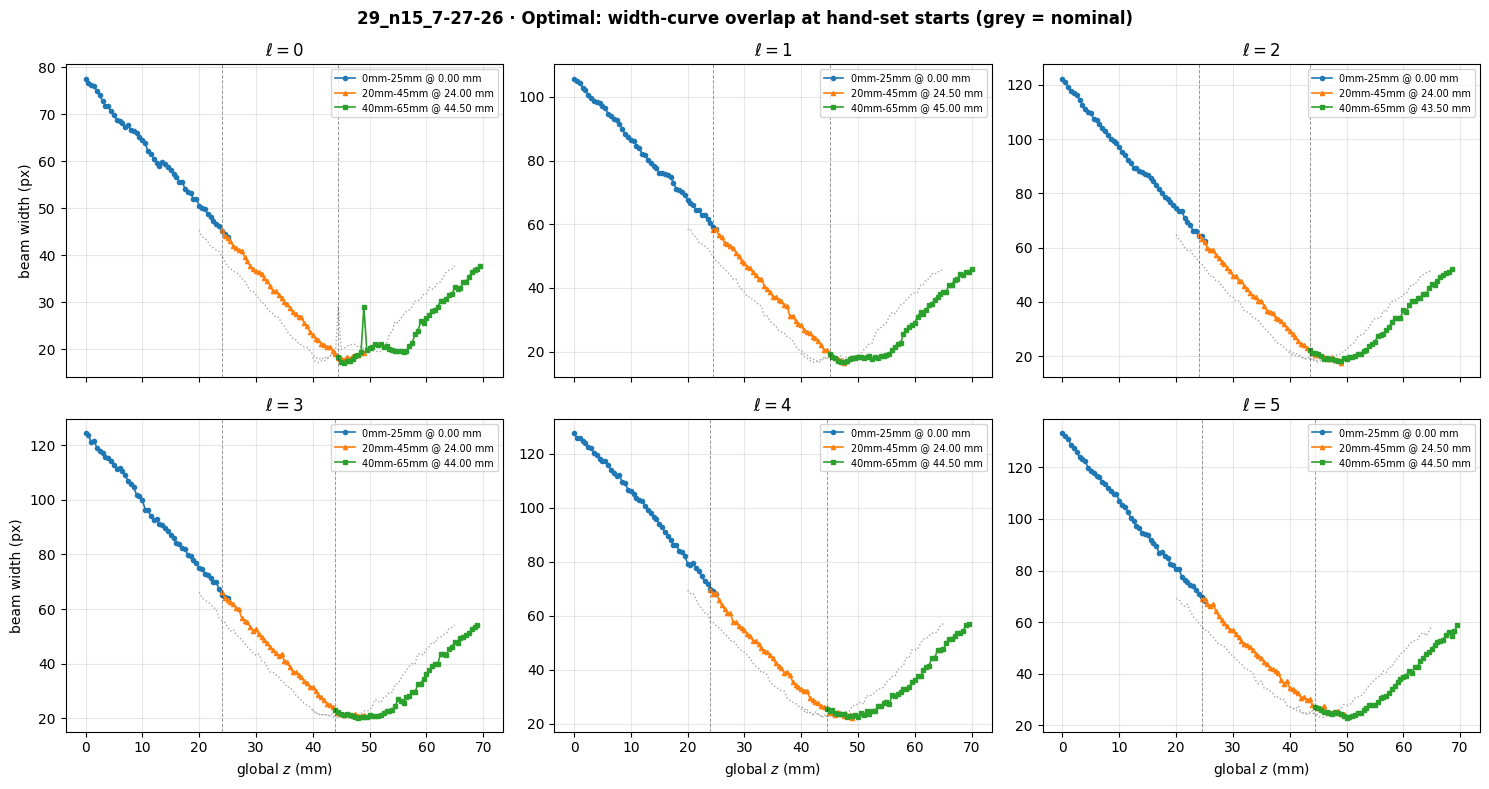

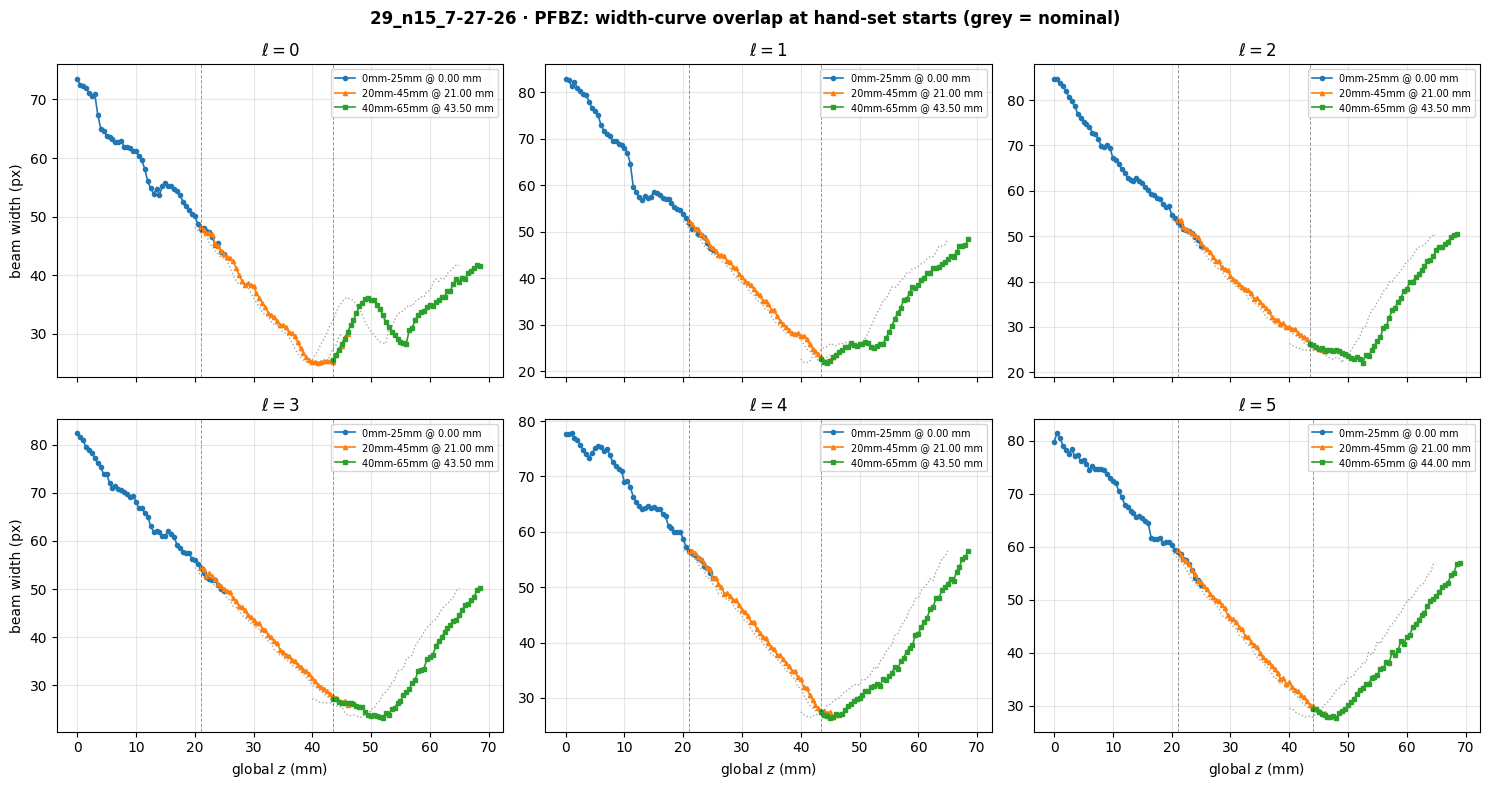

In [31]:
SEG_COLOURS = {seg: f"C{i}" for i, seg in enumerate(
    ["0mm-25mm", "20mm-45mm", "40mm-65mm", "60mm-85mm"])}
SEG_MARKERS = {seg: m for seg, m in zip(
    ["0mm-25mm", "20mm-45mm", "40mm-65mm", "60mm-85mm"], ["o-", "^-", "s-", "d-"])}


def plot_alignment(cond: str):
    ells = list(data[cond])
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
    for ell, ax in zip(ells, axes.ravel()):
        order = seg_order(cond, ell)
        ref = order[0]
        for seg in order:
            sw = data[cond][ell][seg]
            if seg != ref:
                ax.plot(sw.z_local + sw.nominal_start_mm, sw.width_px, ":", ms=2.5, lw=1,
                        color="0.65", zorder=1)
            ax.plot(global_z(sw, ell), sw.width_px, SEG_MARKERS[seg], ms=3, lw=1.2,
                    color=SEG_COLOURS[seg], zorder=2,
                    label=f"{seg} @ {STARTS_MM[cond][ell][seg]:.2f} mm")
        for seg in order[1:]:
            ax.axvline(STARTS_MM[cond][ell][seg], color="k", ls="--", lw=0.7, alpha=0.4)
        ax.set_title(f"$\\ell={ell}$")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(alpha=0.3)
    for ax in axes.ravel()[len(ells):]:
        ax.set_visible(False)
    for ax in axes[:, 0]:
        ax.set_ylabel("beam width (px)")
    for ax in axes[-1, :]:
        ax.set_xlabel("global $z$ (mm)")
    fig.suptitle(f"{RUN} · {cond}: width-curve overlap at hand-set starts (grey = nominal)",
                 fontweight="bold")
    fig.tight_layout()
    fig.savefig(cond_out(cond) / "alignment_diagnostic.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


for cond in CONDITION_SEGMENTS:
    plot_alignment(cond)

### Zoom on each seam

One column per seam, one row per $\ell$, zoomed to just the shared band plus a small margin, showing
only the two segments that meet there. Nudge `start_mm` in `waterfall_offsets.csv` until the curves sit on
each other in every panel. (Conditions/ells with a single segment have no seam and are skipped.)

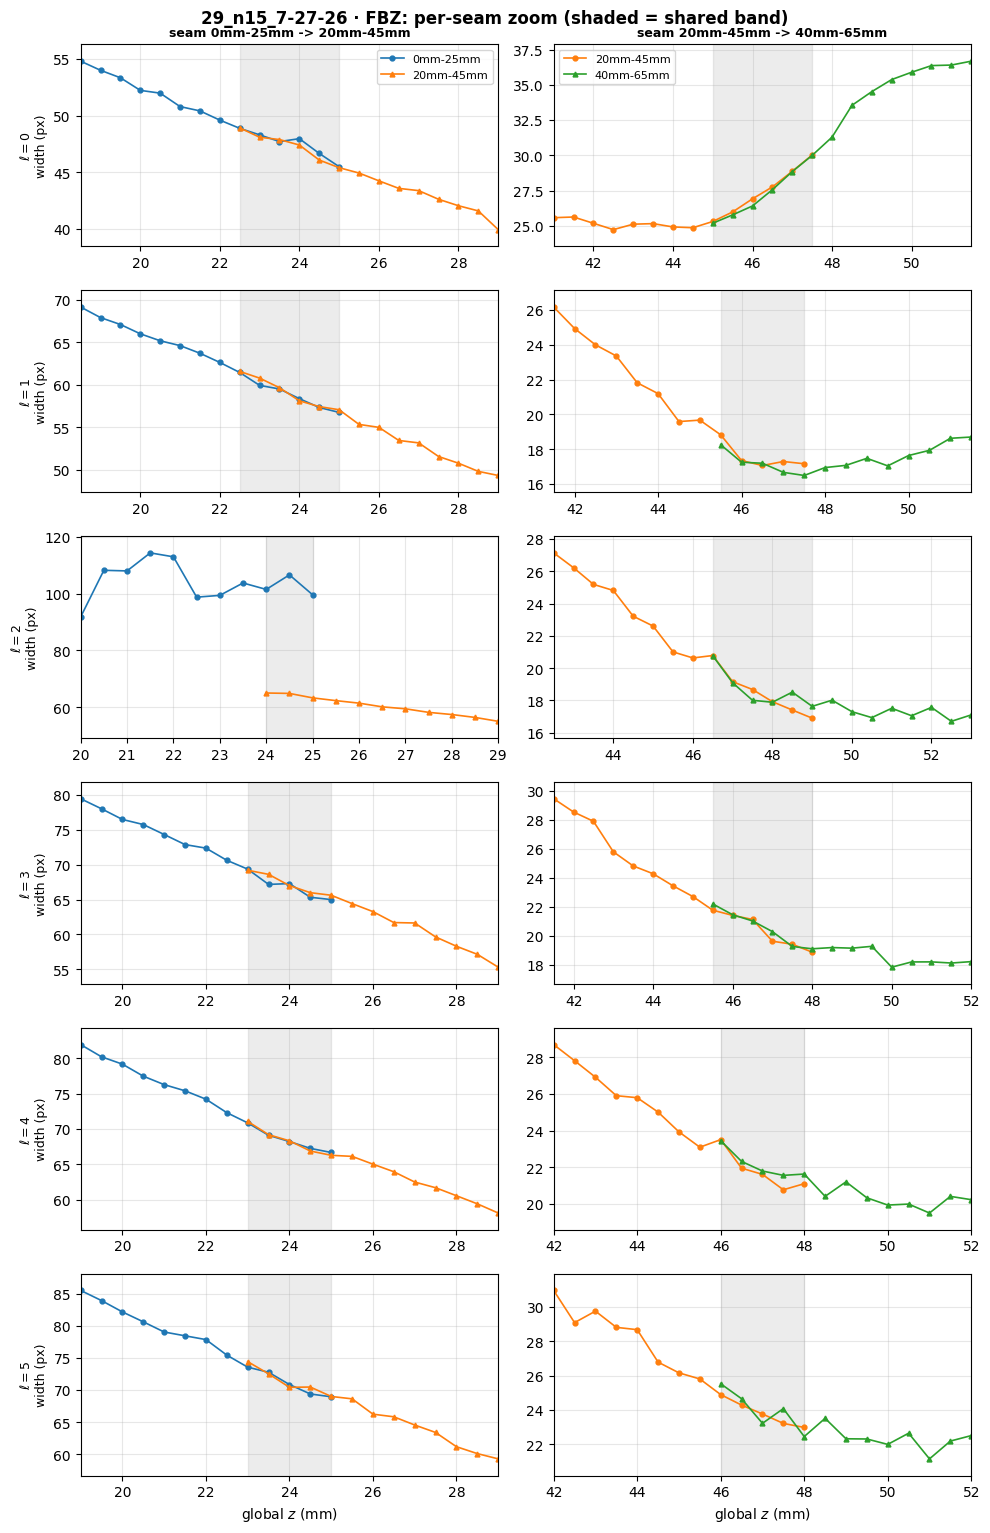

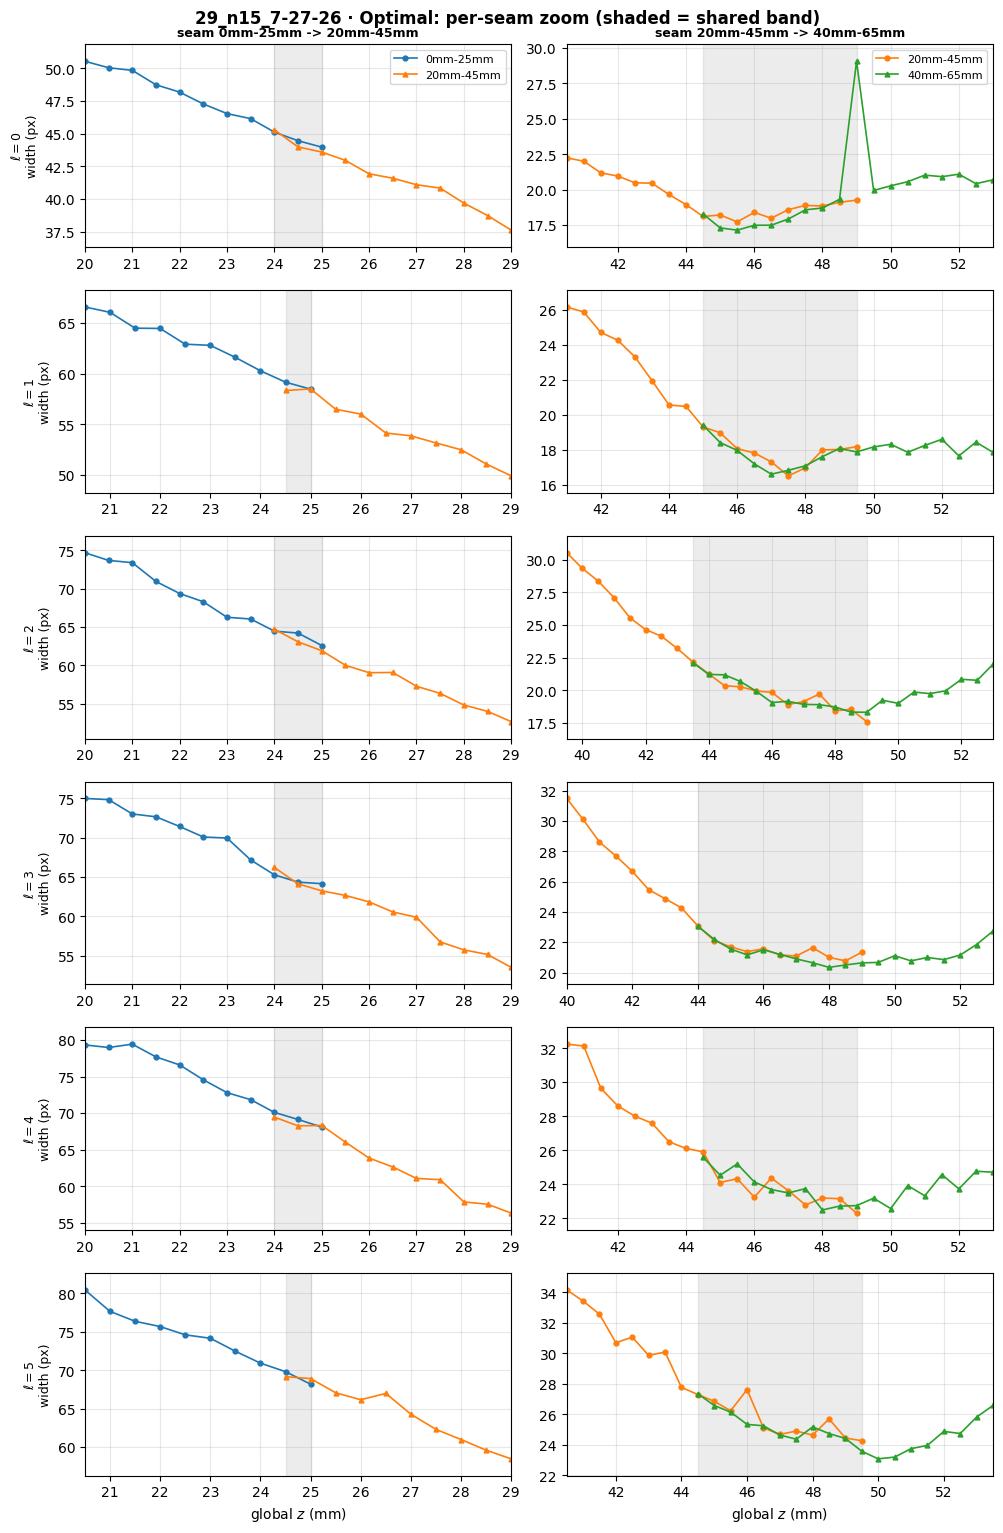

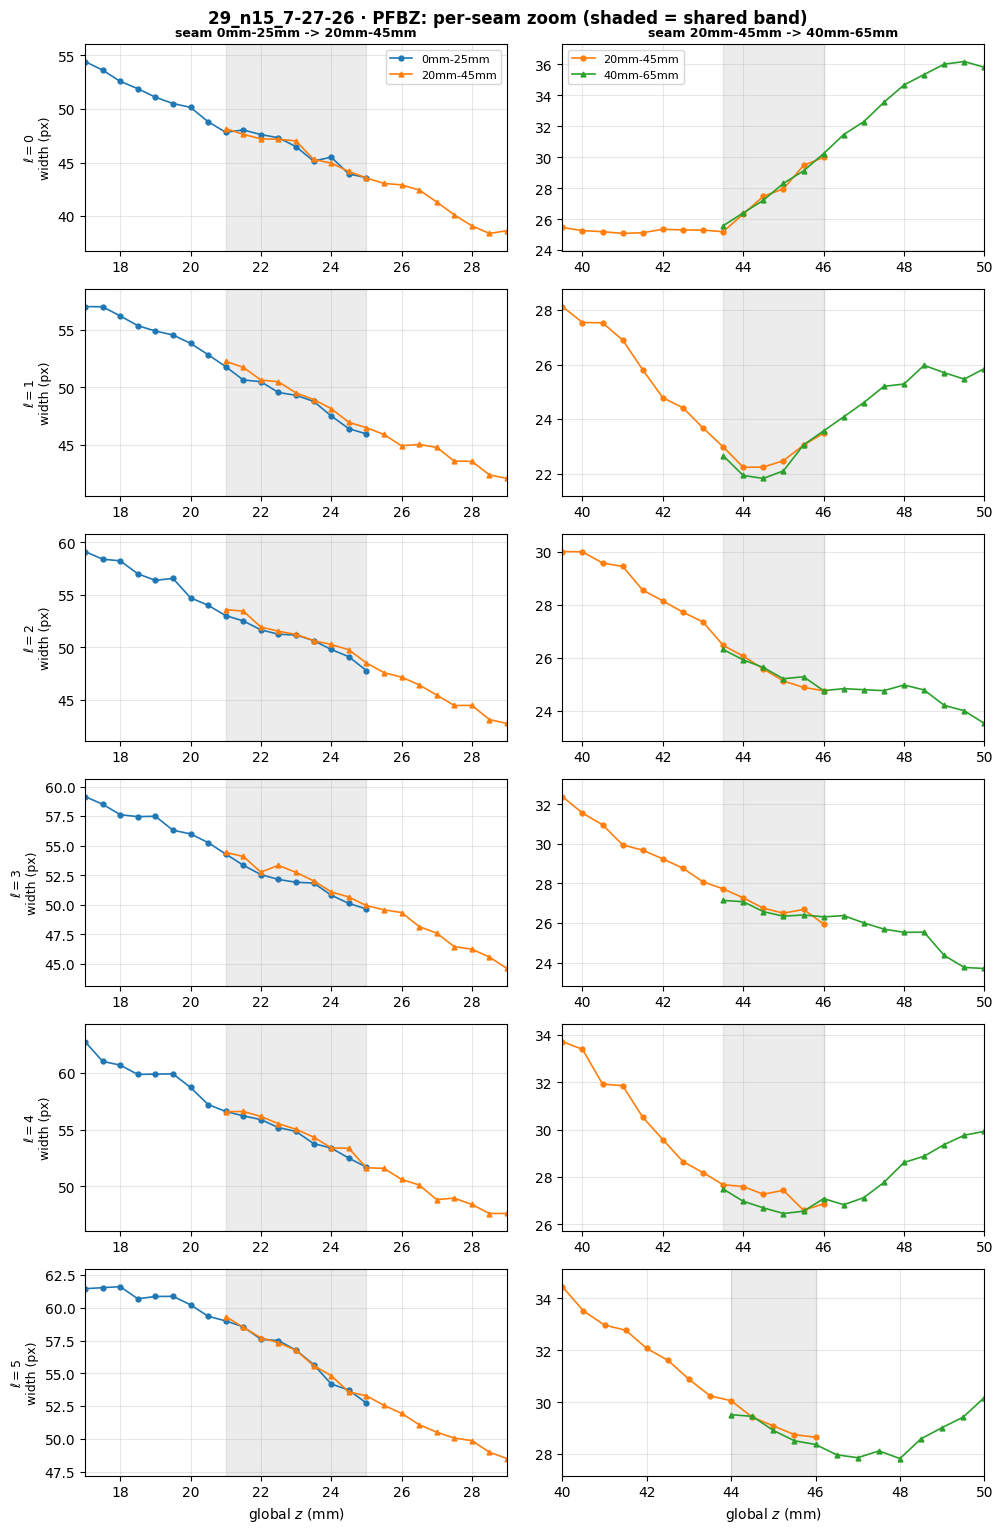

In [32]:
def plot_seam_zoom(cond: str):
    ells = list(data[cond])
    # union of seam positions across ells -> a fixed set of seam columns
    max_seams = max((len(seams(cond, ell)) for ell in ells), default=0)
    if max_seams == 0:
        print(f"{cond}: no seams (single segment) — skipping seam zoom")
        return
    fig, axes = plt.subplots(len(ells), max_seams,
                             figsize=(5.0 * max_seams, 2.6 * len(ells)), squeeze=False)
    for r, ell in enumerate(ells):
        sm = seams(cond, ell)
        for c in range(max_seams):
            ax = axes[r, c]
            if c >= len(sm):
                ax.set_visible(False)
                continue
            left, right = sm[c]
            zl = global_z(data[cond][ell][left], ell)
            zr = global_z(data[cond][ell][right], ell)
            ax.plot(zl, data[cond][ell][left].width_px, "o-", ms=3.5, lw=1.2,
                    color=SEG_COLOURS[left], label=left)
            ax.plot(zr, data[cond][ell][right].width_px, "^-", ms=3.5, lw=1.2,
                    color=SEG_COLOURS[right], label=right)
            lo, hi = max(zl[0], zr[0]), min(zl[-1], zr[-1])
            if hi > lo:
                ax.axvspan(lo, hi, color="grey", alpha=0.15)
                ax.set_xlim(lo - 4, hi + 4)
            else:
                ax.set_xlim(min(zl[-1], zr[0]) - 4, max(zl[-1], zr[0]) + 4)
                ax.text(0.5, 0.9, "no overlap!", transform=ax.transAxes, ha="center",
                        color="crimson", fontweight="bold")
            band = np.concatenate([
                data[cond][ell][left].width_px[(zl >= lo - 4) & (zl <= hi + 4)],
                data[cond][ell][right].width_px[(zr >= lo - 4) & (zr <= hi + 4)],
            ])
            band = band[np.isfinite(band)]
            if band.size:
                pad = 0.1 * (band.max() - band.min() + 1e-9)
                ax.set_ylim(band.min() - pad, band.max() + pad)
            ax.grid(alpha=0.3)
            if r == 0:
                ax.set_title(f"seam {left} -> {right}", fontweight="bold", fontsize=9)
                ax.legend(fontsize=8)
            if c == 0:
                ax.set_ylabel(f"$\\ell={ell}$\nwidth (px)", fontsize=9)
            if r == len(ells) - 1:
                ax.set_xlabel("global $z$ (mm)")
    fig.suptitle(f"{RUN} · {cond}: per-seam zoom (shaded = shared band)", fontweight="bold")
    fig.tight_layout()
    fig.savefig(cond_out(cond) / "seam_zoom.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


for cond in CONDITION_SEGMENTS:
    plot_seam_zoom(cond)

## Stitch all segments onto one global-$z$ grid

Identical stitch to the 3-seg notebook, now parametrised by `(condition, ell)`. Every segment is
resampled onto one uniform global grid by linear interpolation in $z$ (honouring sub-frame offsets),
then blended with per-segment weights normalised so $\sum_k w_k = 1$ wherever anything is covered:

* **crossfade** — a linear hand-over across each pairwise overlap band.
* **average** — equal weight to every segment covering that $z$.
* **hardcut** — the earlier segment wins up to each overlap midpoint, the later one after.

Each blended map is peak-normalised **after** stitching, so colours are comparable across the whole
scan.

In [33]:
BLEND_MODES = ["crossfade", "average", "hardcut"]


@dataclass
class Stitched:
    cond: str
    ell: int
    mode: str
    waterfall: np.ndarray   # (n_z, n_s) peak-normalised, on the common global grid
    s_px: np.ndarray
    z_mm: np.ndarray        # (n_z,) uniform global z
    centroid_y: np.ndarray
    centroid_x: np.ndarray
    coverage: np.ndarray    # (n_z,) how many segments cover each row

    @property
    def brightest_z(self) -> float:
        return float(self.z_mm[self.waterfall.max(axis=1).argmax()])


def _resample_map(z_src: np.ndarray, water_src: np.ndarray, z_grid: np.ndarray):
    '''Linear-interpolate a (n_z, n_s) map from z_src onto z_grid, per transverse column.'''
    covered = (z_grid >= z_src[0] - 1e-9) & (z_grid <= z_src[-1] + 1e-9)
    out = np.zeros((len(z_grid), water_src.shape[1]))
    if covered.any():
        zc = z_grid[covered]
        out[covered] = np.stack(
            [np.interp(zc, z_src, water_src[:, c]) for c in range(water_src.shape[1])], axis=1
        )
    return out, covered


def _blend_weights(mode: str, order: list[str], z_grid: np.ndarray,
                   covers: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    '''Per-segment weight along z, normalised to sum to 1 wherever anything is covered.'''
    order = [lbl for lbl in order if lbl in covers]
    w = {lbl: covers[lbl].astype(float) for lbl in order}

    if mode == "average":
        pass
    elif mode == "hardcut":
        for left, right in zip(order[:-1], order[1:]):
            both = covers[left] & covers[right]
            if not both.any():
                continue
            z_ov = z_grid[both]
            mid = 0.5 * (z_ov.min() + z_ov.max())
            w[left][both] = np.where(z_ov <= mid, 1.0, 0.0)
            w[right][both] = np.where(z_ov <= mid, 0.0, 1.0)
    else:  # crossfade
        for left, right in zip(order[:-1], order[1:]):
            both = covers[left] & covers[right]
            if not both.any():
                continue
            z_ov = z_grid[both]
            lo, hi = z_ov.min(), z_ov.max()
            ramp = np.clip((hi - z_ov) / (hi - lo), 0.0, 1.0) if hi > lo else np.full(z_ov.shape, 0.5)
            w[left][both] = ramp
            w[right][both] = 1.0 - ramp

    stack = np.stack([w[lbl] for lbl in order])
    total = stack.sum(axis=0)
    good = total > 0
    stack[:, good] /= total[good]
    return {lbl: stack[i] for i, lbl in enumerate(order)}


def stitch(cond: str, ell: int, mode: str, z_grid: np.ndarray) -> Stitched:
    order = seg_order(cond, ell)
    sws = {lbl: data[cond][ell][lbl] for lbl in order}
    s_px = sws[order[0]].s_px
    for lbl, sw in sws.items():
        assert np.array_equal(sw.s_px, s_px), f"segment {lbl} cropped to a different extent"

    maps, covers, zs = {}, {}, {}
    for lbl, sw in sws.items():
        z = global_z(sw, ell)
        m, cov = _resample_map(z, sw.waterfall, z_grid)
        maps[lbl], covers[lbl], zs[lbl] = m, cov, z

    weights = _blend_weights(mode, order, z_grid, covers)

    water = np.zeros_like(maps[order[0]])
    for lbl in order:
        water += weights[lbl][:, None] * maps[lbl]

    covered_any = np.any([covers[lbl] for lbl in order], axis=0)
    water[~covered_any] = 0.0
    peak = float(water.max())
    if peak > 0:
        water /= peak

    cy = np.full(z_grid.shape, np.nan)
    cx = np.full(z_grid.shape, np.nan)
    for lbl in order:
        need = np.isnan(cy) & covers[lbl]
        if need.any():
            cy[need] = np.interp(z_grid[need], zs[lbl], sws[lbl].centroid_y)
            cx[need] = np.interp(z_grid[need], zs[lbl], sws[lbl].centroid_x)

    coverage = np.sum([covers[lbl] for lbl in order], axis=0)
    return Stitched(cond, ell, mode, water, s_px, z_grid, cy, cx, coverage)

### Build one global grid + seam bands per condition, then stitch every blend

Each condition gets its own common grid spanning the union of its placed segments (across its ells),
and its own list of seam bands (median overlap across ells) for the reference lines.

In [34]:
# stitched[cond][ell][mode] = Stitched ; plus per-condition grids and seam bands.
stitched: dict[str, dict[int, dict[str, Stitched]]] = {}
Z_GRID: dict[str, np.ndarray] = {}
SEAM_BANDS: dict[str, list[tuple[float, float]]] = {}

for cond in CONDITION_SEGMENTS:
    ells = list(data[cond])
    z_hi = max(global_z(data[cond][ell][s], ell)[-1] for ell in ells for s in seg_order(cond, ell))
    z_lo = min(global_z(data[cond][ell][s], ell)[0] for ell in ells for s in seg_order(cond, ell))
    grid = np.arange(z_lo, z_hi + 0.5 * STEP_MM, STEP_MM)
    Z_GRID[cond] = grid

    # seam bands: for each consecutive folder pair, median overlap across the ells that have both
    bands = []
    for left, right in zip(CONDITION_SEGMENTS[cond][:-1], CONDITION_SEGMENTS[cond][1:]):
        los, his = [], []
        for ell in ells:
            if left in data[cond][ell] and right in data[cond][ell]:
                los.append(global_z(data[cond][ell][right], ell)[0])
                his.append(global_z(data[cond][ell][left], ell)[-1])
        if los:
            bands.append((float(np.median(los)), float(np.median(his))))
    SEAM_BANDS[cond] = bands

    stitched[cond] = {ell: {} for ell in ells}
    for ell in ells:
        for mode in BLEND_MODES:
            stitched[cond][ell][mode] = stitch(cond, ell, mode, grid)
        st = stitched[cond][ell]["crossfade"]
        gaps = int((st.coverage == 0).sum())
        note = f"  !! {gaps} uncovered rows" if gaps else ""
        print(f"{cond:>8} l={ell}: {st.waterfall.shape}  z {st.z_mm.min():.1f}..{st.z_mm.max():.1f} mm"
              f"  brightest {st.brightest_z:.1f} mm{note}")
    print(f"         grid {grid.size} rows {grid[0]:.1f}..{grid[-1]:.1f} mm | "
          f"seams " + ", ".join(f"{lo:.1f}-{hi:.1f}" for lo, hi in bands))

     FBZ l=0: (144, 401)  z 0.0..71.5 mm  brightest 47.0 mm  !! 3 uncovered rows
     FBZ l=1: (144, 401)  z 0.0..71.5 mm  brightest 46.5 mm  !! 2 uncovered rows
     FBZ l=2: (144, 401)  z 0.0..71.5 mm  brightest 49.0 mm
     FBZ l=3: (144, 401)  z 0.0..71.5 mm  brightest 50.5 mm  !! 2 uncovered rows
     FBZ l=4: (144, 401)  z 0.0..71.5 mm  brightest 51.0 mm  !! 1 uncovered rows
     FBZ l=5: (144, 401)  z 0.0..71.5 mm  brightest 51.0 mm  !! 1 uncovered rows
         grid 144 rows 0.0..71.5 mm | seams 23.0-25.0, 45.8-48.0
 Optimal l=0: (141, 401)  z 0.0..70.0 mm  brightest 43.5 mm  !! 1 uncovered rows
 Optimal l=1: (141, 401)  z 0.0..70.0 mm  brightest 47.5 mm
 Optimal l=2: (141, 401)  z 0.0..70.0 mm  brightest 50.0 mm  !! 3 uncovered rows
 Optimal l=3: (141, 401)  z 0.0..70.0 mm  brightest 49.5 mm  !! 2 uncovered rows
 Optimal l=4: (141, 401)  z 0.0..70.0 mm  brightest 50.5 mm  !! 1 uncovered rows
 Optimal l=5: (141, 401)  z 0.0..70.0 mm  brightest 49.5 mm  !! 1 uncovered rows
     

## Compare the three overlap blends

One row per $\ell$, one column per blend mode, per condition, sharing the $z$ axis and a single 0–1
colourbar. Dashed lines mark the seam bands. With the segments correctly co-registered the caustic
arms should run **straight through every seam with no kink**.

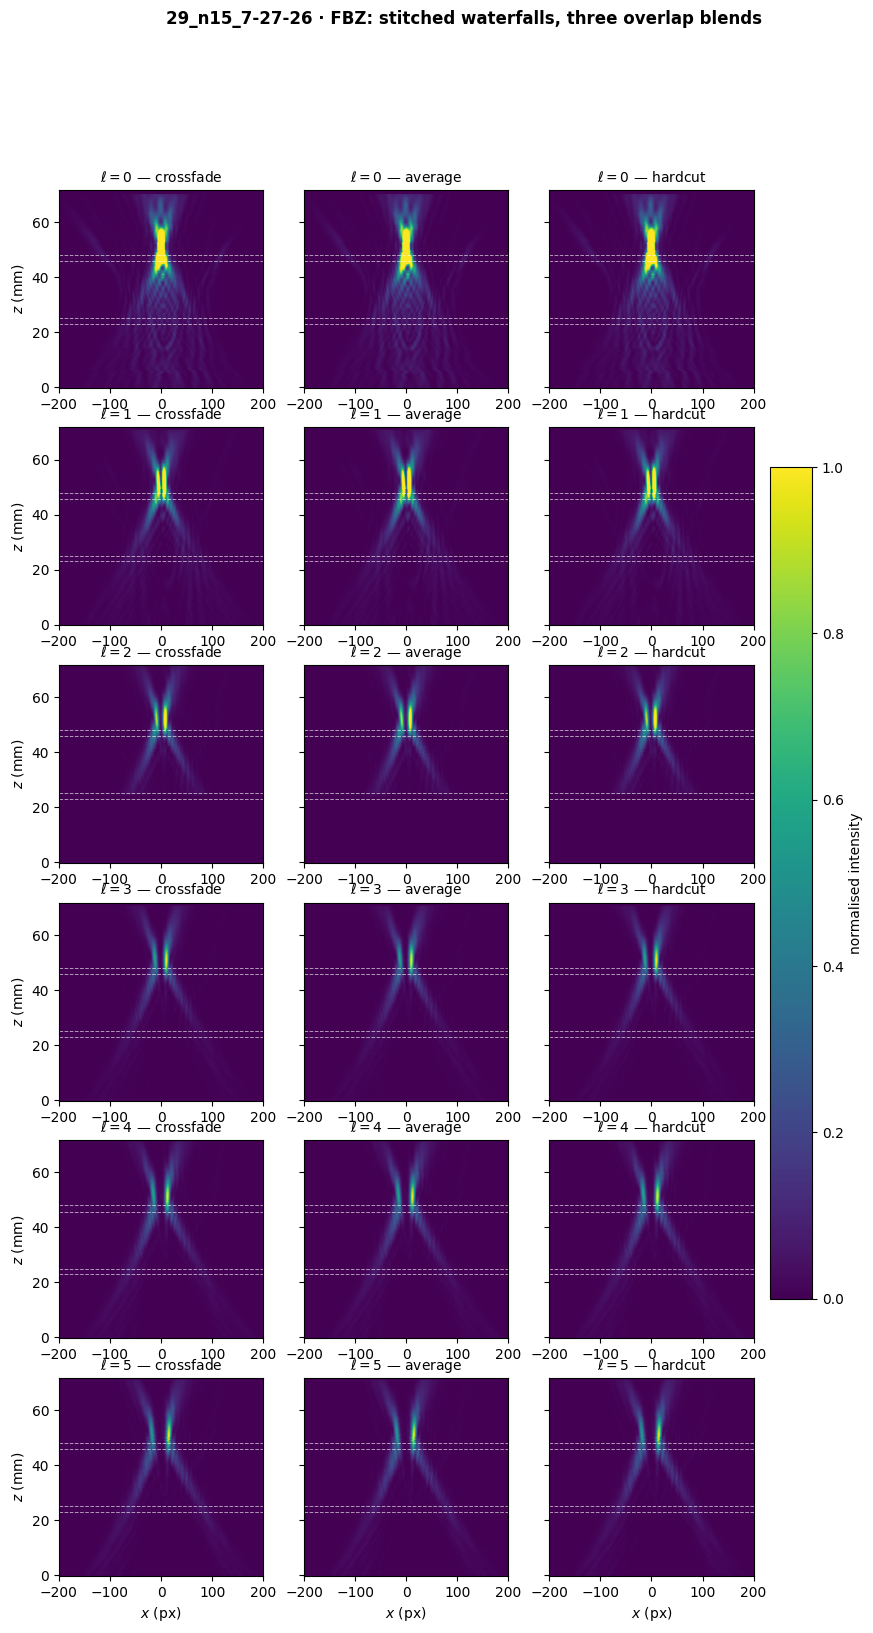

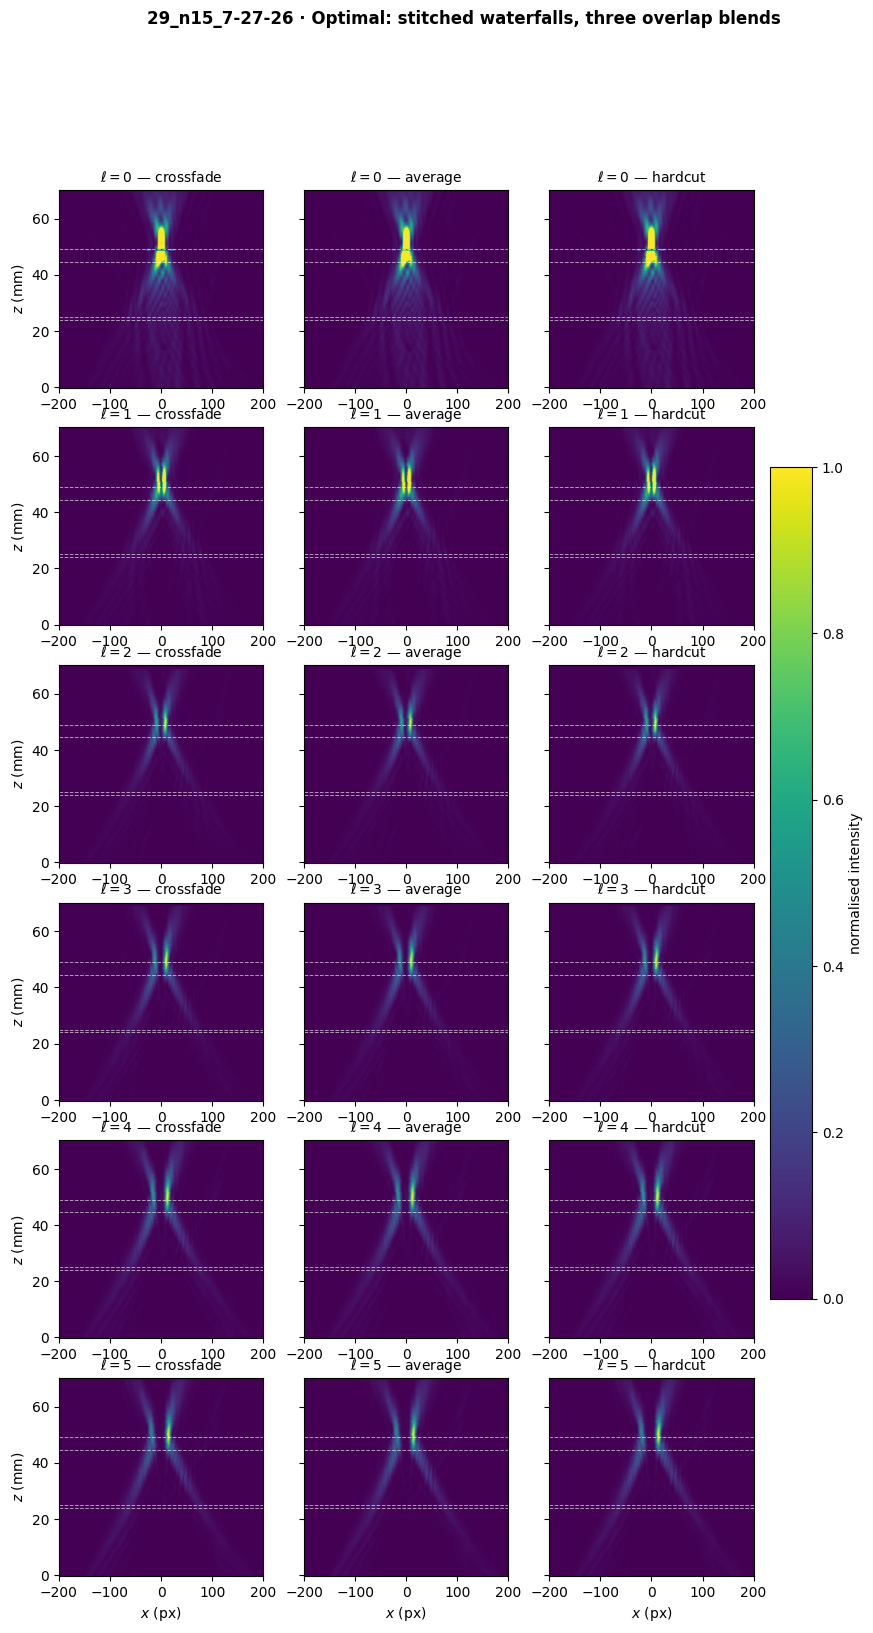

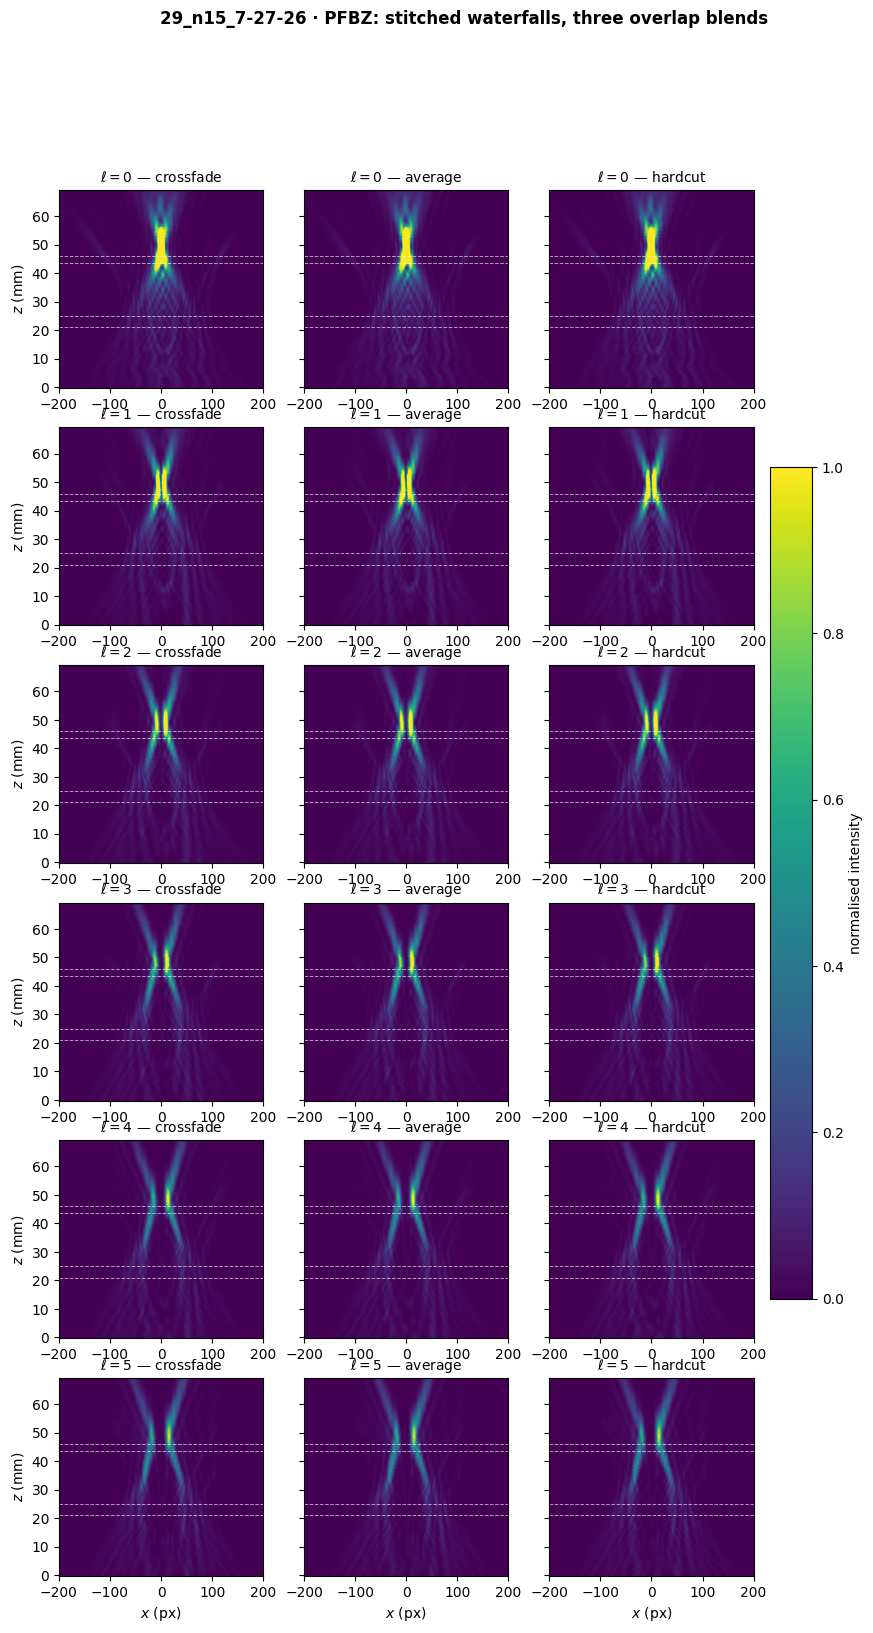

In [35]:
def draw_waterfall(ax, water, s_px, z_mm, title):
    dz = float(np.median(np.diff(z_mm))) if z_mm.size > 1 else STEP_MM
    im = ax.imshow(water, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=1,
                   extent=[s_px[0], s_px[-1], z_mm[0] - dz / 2, z_mm[-1] + dz / 2])
    ax.set_xlabel(f"${SLICE_AXIS}$ (px)")
    ax.set_ylabel("$z$ (mm)")
    ax.set_title(title, fontsize=10)
    return im


def plot_blend_grid(cond: str):
    ells = list(data[cond])
    fig, axes = plt.subplots(len(ells), len(BLEND_MODES),
                             figsize=(3.2 * len(BLEND_MODES) + 1.2, 3.0 * len(ells)),
                             sharey=True, squeeze=False)
    im = None
    for r, ell in enumerate(ells):
        for c, mode in enumerate(BLEND_MODES):
            st = stitched[cond][ell][mode]
            im = draw_waterfall(axes[r, c], st.waterfall, st.s_px, st.z_mm,
                                f"$\\ell={ell}$ — {mode}")
            for lo, hi in SEAM_BANDS[cond]:
                for y in (lo, hi):
                    axes[r, c].axhline(y, color="w", ls="--", lw=0.7, alpha=0.6)
            if c > 0:
                axes[r, c].set_ylabel("")
            if r < len(ells) - 1:
                axes[r, c].set_xlabel("")
    fig.colorbar(im, ax=axes.ravel().tolist(), label="normalised intensity", pad=0.02, shrink=0.6)
    fig.suptitle(f"{RUN} · {cond}: stitched waterfalls, three overlap blends", fontweight="bold")
    fig.savefig(cond_out(cond) / "blend_comparison_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


for cond in CONDITION_SEGMENTS:
    plot_blend_grid(cond)

## Final stitched waterfalls (chosen blend)

Set `CHOSEN_BLEND` to whichever read cleanest above. Per condition this writes one PNG per $\ell$
under `outputs/waterfalls_stitched_full/<cond>/l=<n>_<axis>.png` plus the per-condition grid.

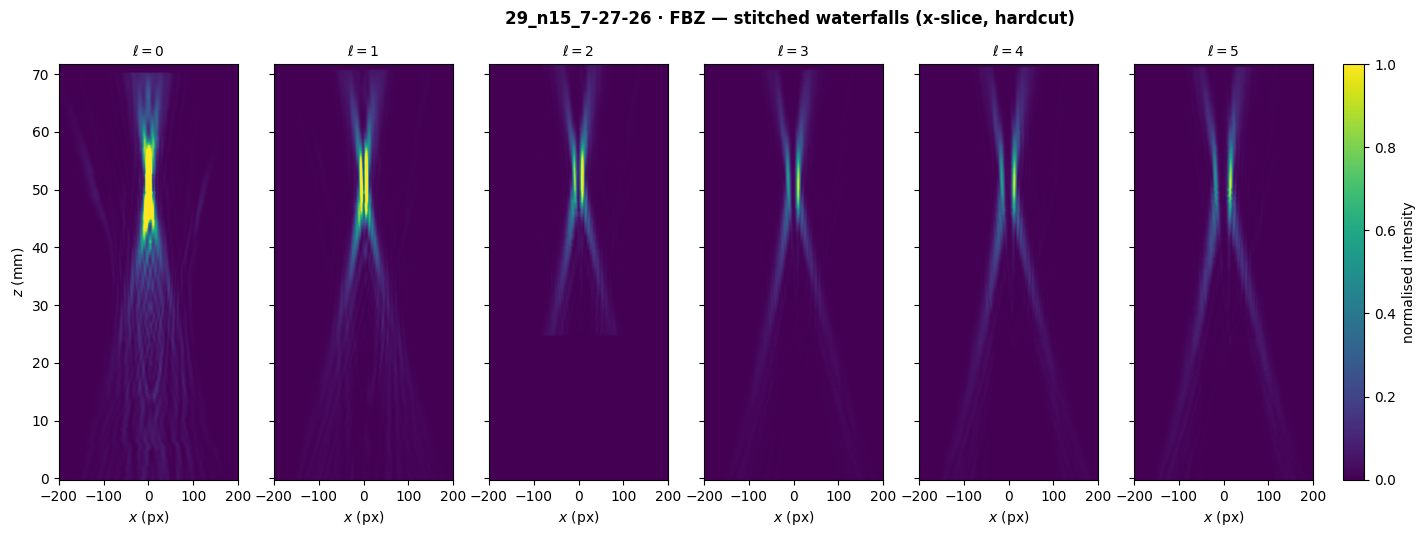

FBZ: saved per-ell PNGs + grid to outputs/waterfalls_stitched_full/FBZ


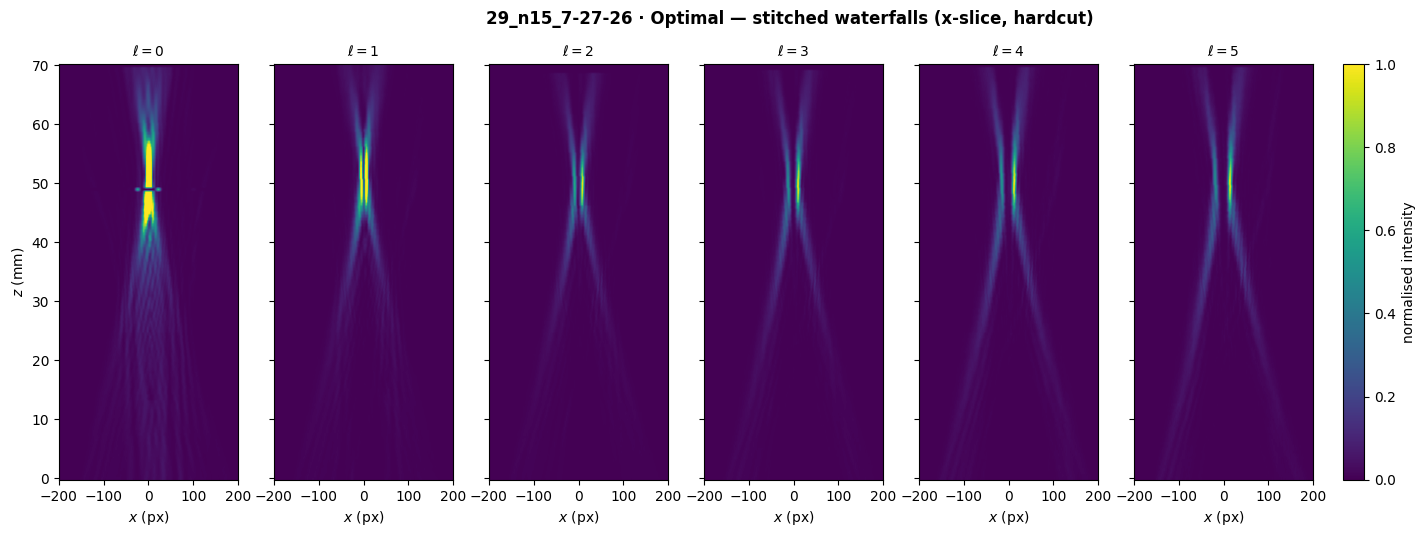

Optimal: saved per-ell PNGs + grid to outputs/waterfalls_stitched_full/Optimal


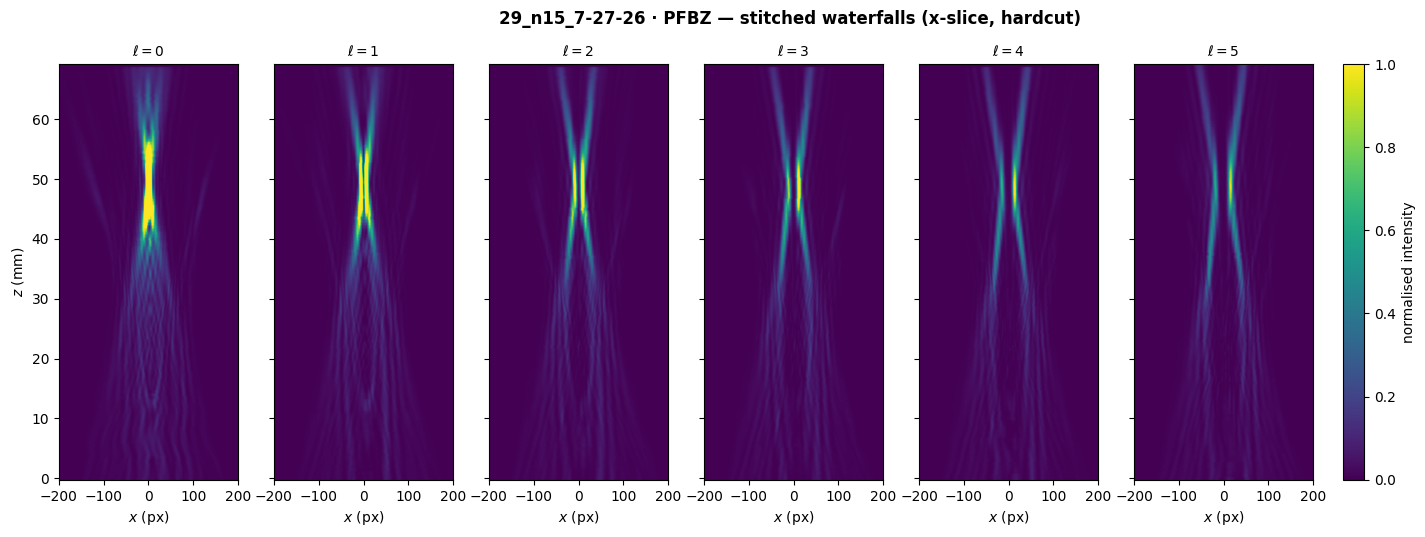

PFBZ: saved per-ell PNGs + grid to outputs/waterfalls_stitched_full/PFBZ


In [36]:
CHOSEN_BLEND = "hardcut"   # <- set to "crossfade" or "average" after eyeballing the grids above
assert CHOSEN_BLEND in BLEND_MODES


def plot_final(cond: str):
    ells = list(data[cond])
    group = [stitched[cond][ell][CHOSEN_BLEND] for ell in ells]
    fig, axes = plt.subplots(1, len(group), figsize=(3.0 * len(group) + 1.5, 5.4),
                             sharey=True, squeeze=False)
    im = None
    for ax, st in zip(axes[0], group):
        im = draw_waterfall(ax, st.waterfall, st.s_px, st.z_mm, f"$\\ell={st.ell}$")
        ax.set_ylabel("")
    axes[0, 0].set_ylabel("$z$ (mm)")
    fig.colorbar(im, ax=axes[0].tolist(), label="normalised intensity", pad=0.02)
    fig.suptitle(f"{RUN} · {cond} — stitched waterfalls ({SLICE_AXIS}-slice, {CHOSEN_BLEND})",
                 fontweight="bold")
    fig.savefig(cond_out(cond) / f"{cond}_grid_{SLICE_AXIS}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    for st in group:
        f, a = plt.subplots(figsize=(5.5, 6.0))
        im = draw_waterfall(a, st.waterfall, st.s_px, st.z_mm,
                            f"{RUN} · {cond}  $\\ell={st.ell}$  ({CHOSEN_BLEND})")
        f.colorbar(im, ax=a, label="normalised intensity")
        f.tight_layout()
        f.savefig(cond_out(cond) / f"l={st.ell}_{SLICE_AXIS}.png", dpi=150)
        plt.close(f)
    print(f"{cond}: saved per-ell PNGs + grid to {cond_out(cond).relative_to(REPO_ROOT)}")


for cond in CONDITION_SEGMENTS:
    plot_final(cond)

## Beam width across the full stitched scan

Transverse RMS beam width of the **stitched** waterfall, per $\ell$, over the whole combined range,
per condition. Seam bands shaded; smooth width curves through them confirm the stitch is clean.
Focus is where each curve bottoms out.

**Note on $\ell=0$:** it is a Gaussian, not a donut, and its width has no sharp match between
segments, so small steps at the seams are expected and do not affect the donut results.

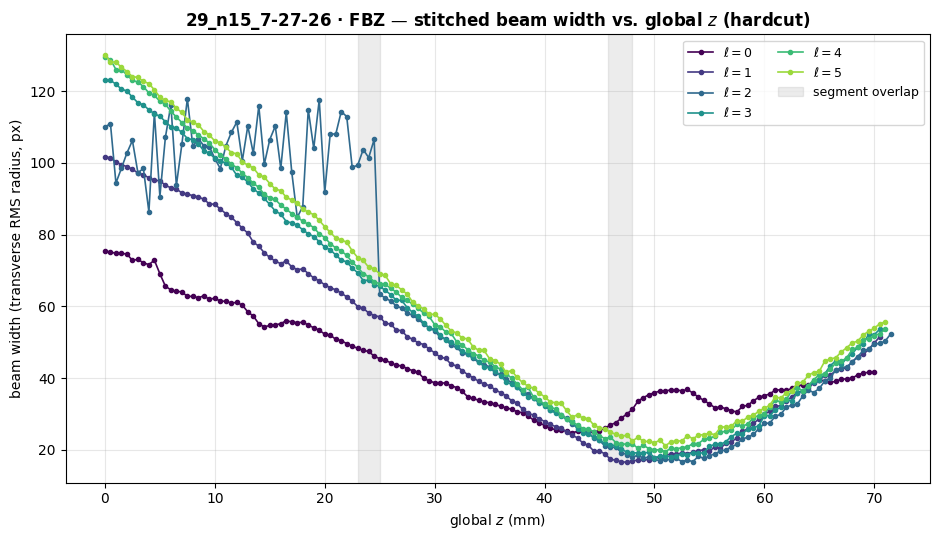

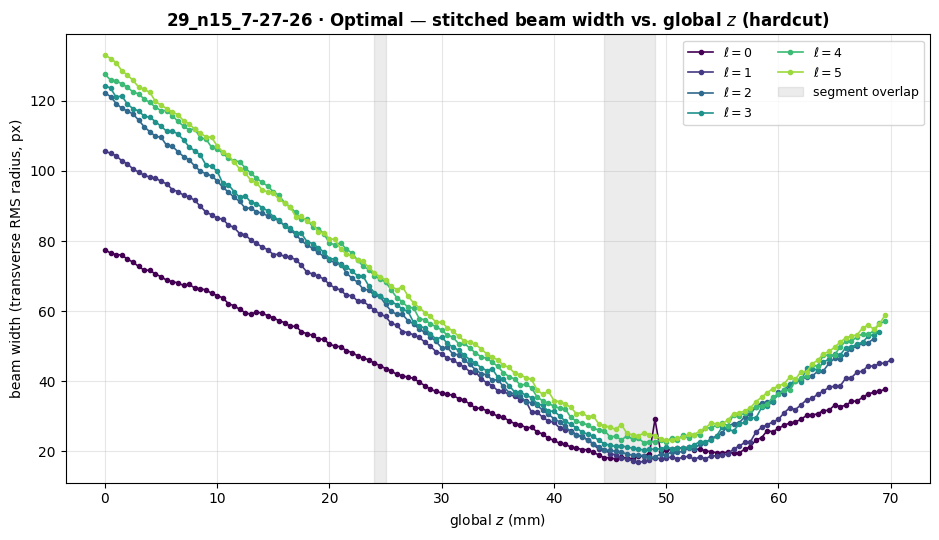

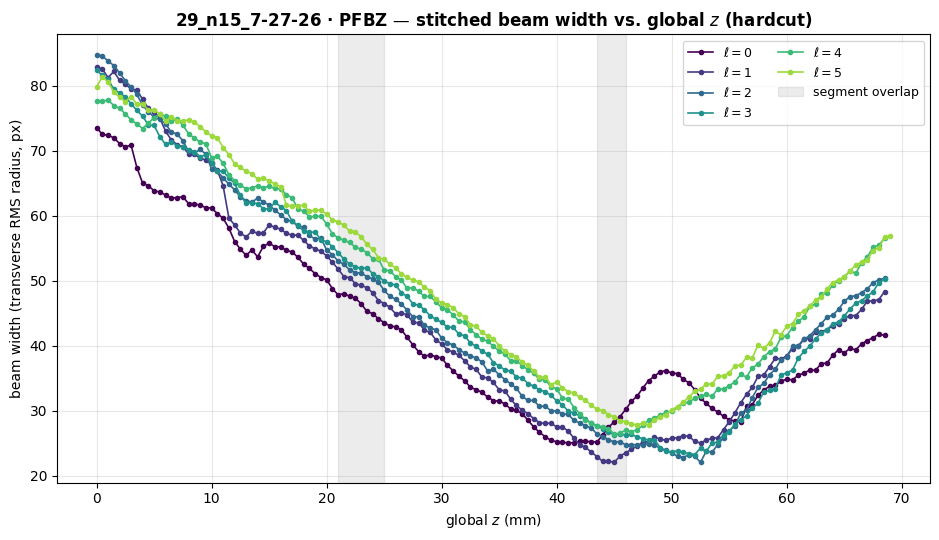

width minimum (focus) per condition / ell:


,condition,ell,z_focus_mm,min_width_px
0,FBZ,0,42.5,24.73
1,FBZ,1,47.5,16.50
2,FBZ,2,53.5,16.71
3,FBZ,3,50.0,17.83
4,FBZ,4,51.0,19.51
5,FBZ,5,51.0,21.15
6,Optimal,0,45.5,17.72
7,Optimal,1,47.5,16.84
8,Optimal,2,49.0,18.32
9,Optimal,3,48.0,20.35


In [37]:
def stitched_width(st):
    return np.array([_rms_width(row, st.s_px) for row in st.waterfall])


focus_all = []


def plot_width(cond: str):
    ells = list(data[cond])
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    colours = plt.get_cmap("viridis")(np.linspace(0, 0.85, len(ells)))
    for ell, colour in zip(ells, colours):
        st = stitched[cond][ell][CHOSEN_BLEND]
        w = stitched_width(st)
        ax.plot(st.z_mm, w, "o-", ms=3, lw=1.2, color=colour, label=f"$\\ell={ell}$")
        ok = np.isfinite(w) & (st.coverage > 0)
        if ok.any():
            focus_all.append({
                "condition": cond, "ell": ell,
                "z_focus_mm": float(st.z_mm[ok][np.nanargmin(w[ok])]),
                "min_width_px": float(np.nanmin(w[ok])),
            })
    for i, (lo, hi) in enumerate(SEAM_BANDS[cond]):
        ax.axvspan(lo, hi, color="grey", alpha=0.15,
                   label="segment overlap" if i == 0 else None)
    ax.set_xlabel("global $z$ (mm)")
    ax.set_ylabel("beam width (transverse RMS radius, px)")
    ax.set_title(f"{RUN} · {cond} — stitched beam width vs. global $z$ ({CHOSEN_BLEND})",
                 fontweight="bold")
    ax.legend(ncol=2, fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(cond_out(cond) / f"{cond}_stitched_width.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


for cond in CONDITION_SEGMENTS:
    plot_width(cond)

focus_table = pd.DataFrame(focus_all).round(2)
print("width minimum (focus) per condition / ell:")
display(focus_table)

## Per-frame Laguerre–Gaussian fit — LG mode matched to each frame

Instead of the empirical RMS above, here every **individual frame** of the stitched waterfall is fitted to the transverse profile of a Laguerre–Gaussian $\mathrm{LG}_{0,\ell}$ mode, using the **actual $\ell$** of that curve. This is *not* a propagation model: each frame gets its own LG mode whose spot-size parameter $w(z)$ is whatever best matches the beam at that distance. The $\ell=0$ curve is an ordinary Gaussian and is included.

The 1-D intensity along a centred diameter of $\mathrm{LG}_{0,\ell}$ is $I(s)=A\,(2s^2/w^2)^{|\ell|}\,e^{-2s^2/w^2}$, whose RMS radius is $(w/2)\sqrt{2|\ell|+1}$. The plot below shows the measured RMS (points) with this **fitted LG RMS model overlaid** (line), and marks the **focus** — the minimum of the model — for each $\ell$.

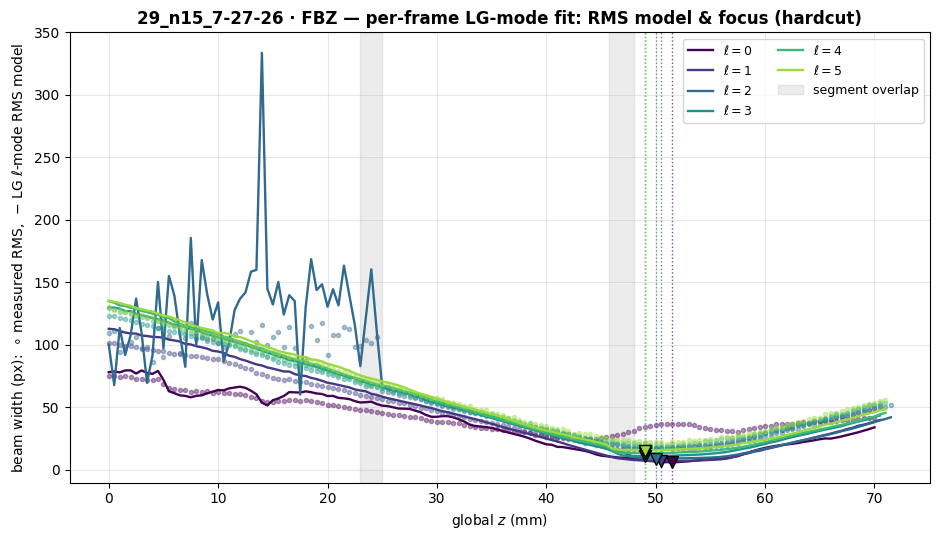

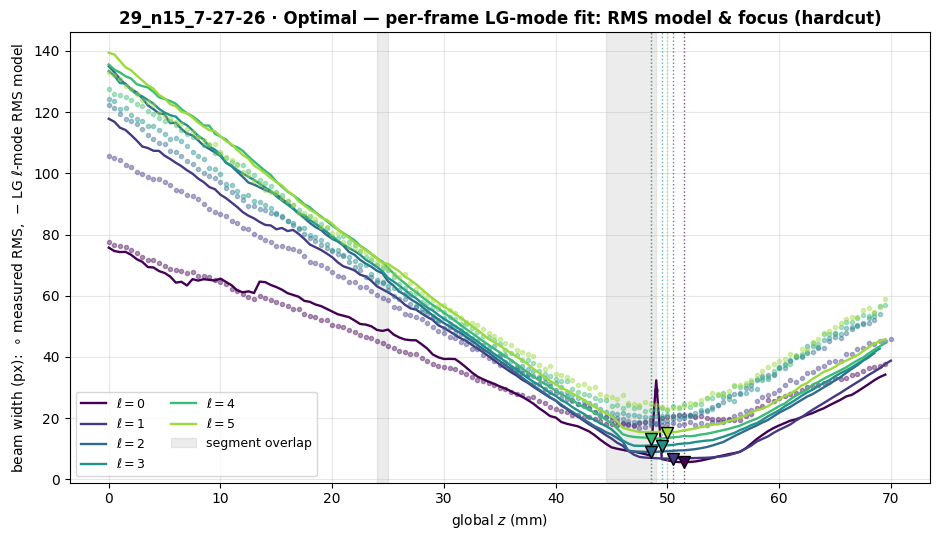

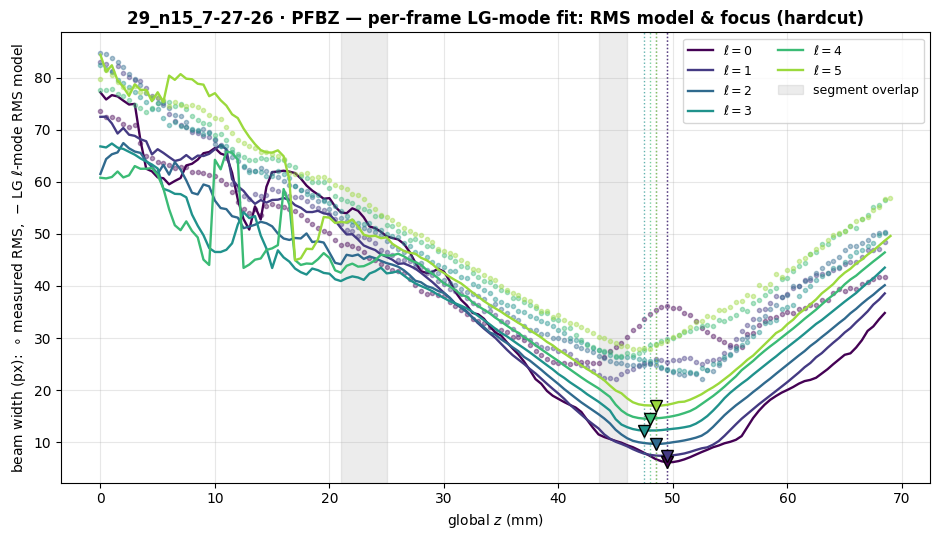

LG-mode fit — focus (minimum of RMS model) per condition / ell:


,condition,ell,z_focus_mm,waist_w_px,rms_model_px
0,FBZ,0,51.5,12.33,6.17
1,FBZ,1,50.5,8.07,6.99
2,FBZ,2,50.0,8.12,9.07
3,FBZ,3,49.0,8.33,11.02
4,FBZ,4,49.0,8.89,13.34
5,FBZ,5,49.0,9.34,15.49
6,Optimal,0,51.5,11.22,5.61
7,Optimal,1,50.5,7.83,6.78
8,Optimal,2,48.5,8.04,8.99
9,Optimal,3,49.5,8.26,10.92


In [38]:
# --- Per-frame LG fit: model an LG_{0,ell} mode at each frame (correct ell per curve) ---
from functools import partial
from scipy.optimize import curve_fit


def lg_line_profile(s, amp, w, ell):
    """Intensity along a centred diameter of LG_{0,|ell|}: A (2 s^2/w^2)^|ell| e^{-2 s^2/w^2}.
    ell=0 reduces to a Gaussian A exp(-2 s^2/w^2); w is the LG spot-size parameter (px)."""
    x = 2.0 * (np.asarray(s, float) ** 2) / (w * w)
    return amp * x ** abs(ell) * np.exp(-x)


def lg_rms_from_w(w, ell):
    """1-D RMS radius of that centred LG diameter: (w/2) sqrt(2|ell|+1)."""
    return 0.5 * np.asarray(w, float) * np.sqrt(2 * abs(ell) + 1)


def fit_lg_frame(profile, s_px, ell):
    """Fit one frame's transverse slice to an LG_{0,ell} diameter; return the waist w (px) or nan."""
    y = np.clip(np.asarray(profile, float), 0, None)
    if not np.isfinite(y).any() or y.max() <= 0:
        return np.nan
    rms = _rms_width(y, s_px)                       # measured 1-D RMS -> waist seed
    if not np.isfinite(rms) or rms <= 0:
        return np.nan
    w0 = 2.0 * rms / np.sqrt(2 * abs(ell) + 1)
    amp0 = y.max() / max((abs(ell) ** abs(ell)) * np.exp(-abs(ell)), 1e-9)
    try:
        popt, _ = curve_fit(partial(lg_line_profile, ell=ell), s_px, y,
                            p0=(amp0, max(w0, 1.0)),
                            bounds=([0.0, 1e-3], [np.inf, np.inf]), maxfev=10000)
    except (RuntimeError, ValueError):
        return np.nan
    return float(popt[1])


def lg_fit_stitched(st):
    """Per-frame LG waist w(z) and the model RMS width, over a stitched waterfall."""
    w_fit = np.array([
        fit_lg_frame(row, st.s_px, st.ell) if cov > 0 else np.nan
        for row, cov in zip(st.waterfall, st.coverage)
    ])
    return w_fit, lg_rms_from_w(w_fit, st.ell)


lg_focus_all = []


def plot_lg_width(cond: str):
    ells = list(data[cond])
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    colours = plt.get_cmap("viridis")(np.linspace(0, 0.85, len(ells)))
    for ell, colour in zip(ells, colours):
        st = stitched[cond][ell][CHOSEN_BLEND]
        meas = stitched_width(st)                    # empirical 1-D RMS (points)
        w_fit, rms_model = lg_fit_stitched(st)       # per-frame LG fit -> waist, model RMS
        ax.plot(st.z_mm, meas, "o", ms=3, color=colour, alpha=0.40)
        ax.plot(st.z_mm, rms_model, "-", lw=1.7, color=colour, label=rf"$\ell={ell}$")
        ok = np.isfinite(rms_model) & (st.coverage > 0)
        if ok.any():
            j = int(np.nanargmin(rms_model[ok]))
            z_focus = float(st.z_mm[ok][j])
            ax.axvline(z_focus, color=colour, ls=":", lw=1.0, alpha=0.7)
            ax.plot(z_focus, float(rms_model[ok][j]), "v", color=colour, ms=9,
                    markeredgecolor="k", zorder=5)
            lg_focus_all.append({
                "condition": cond, "ell": ell,
                "z_focus_mm": round(z_focus, 2),
                "waist_w_px": round(float(w_fit[ok][j]), 2),
                "rms_model_px": round(float(rms_model[ok][j]), 2),
            })
    for i, (lo, hi) in enumerate(SEAM_BANDS[cond]):
        ax.axvspan(lo, hi, color="grey", alpha=0.15,
                   label="segment overlap" if i == 0 else None)
    ax.set_xlabel("global $z$ (mm)")
    ax.set_ylabel(r"beam width (px):  $\circ$ measured RMS,  $-$ LG $\ell$-mode RMS model")
    ax.set_title(f"{RUN} · {cond} — per-frame LG-mode fit: RMS model & focus ({CHOSEN_BLEND})",
                 fontweight="bold")
    ax.legend(ncol=2, fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(cond_out(cond) / f"{cond}_stitched_lg_width.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


for cond in CONDITION_SEGMENTS:
    plot_lg_width(cond)

lg_focus_table = pd.DataFrame(lg_focus_all)
print("LG-mode fit — focus (minimum of RMS model) per condition / ell:")
display(lg_focus_table)


## Beam waist grid — RMS vs LG, across the full stitched scan

The two beam-waist measures side by side over the whole combined range, one column per condition and one row per measure: **top** the empirical RMS radius (as in the section above), **bottom** the per-frame **LG-fitted waist** $w(z)$ using the correct $\ell$ for each curve. Six panels in all (2 measures × 3 conditions). Seam bands shaded; the $y$-axis is shared within each row so the three conditions are directly comparable for a given measure.

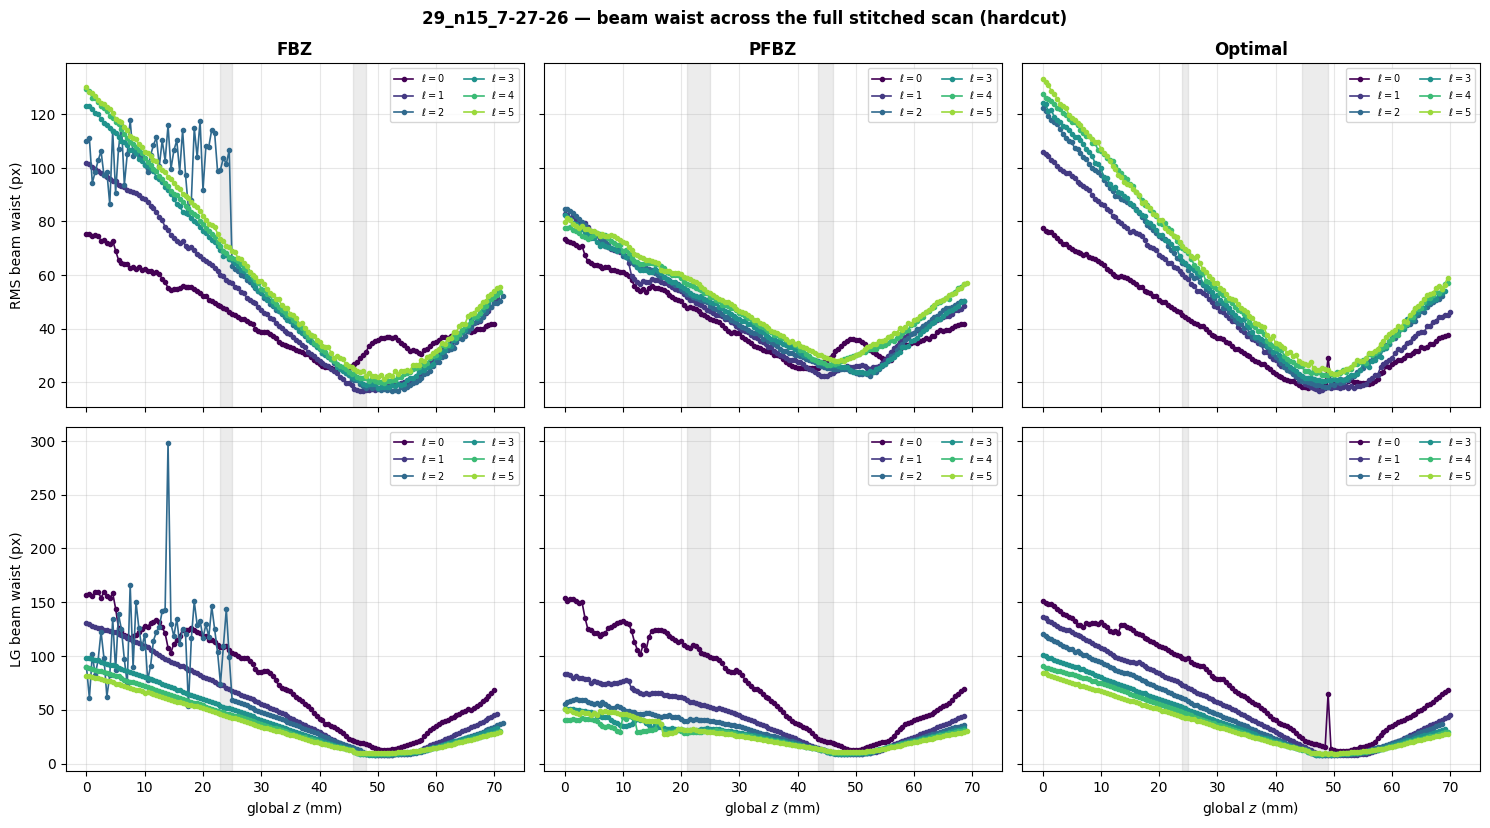

In [39]:
def plot_waist_grid():
    conds = [c for c in ["FBZ", "PFBZ", "Optimal"] if c in CONDITION_SEGMENTS]
    measures = ["RMS beam waist", "LG beam waist"]
    fig, axes = plt.subplots(len(measures), len(conds),
                             figsize=(5.0 * len(conds), 4.2 * len(measures)),
                             sharex=True, sharey="row", squeeze=False)
    for r, measure in enumerate(measures):
        for c, cond in enumerate(conds):
            ax = axes[r, c]
            ells = list(data[cond])
            colours = plt.get_cmap("viridis")(np.linspace(0, 0.85, len(ells)))
            for ell, colour in zip(ells, colours):
                st = stitched[cond][ell][CHOSEN_BLEND]
                y = stitched_width(st) if r == 0 else lg_fit_stitched(st)[0]
                ax.plot(st.z_mm, y, "o-", ms=3, lw=1.2, color=colour, label=rf"$\ell={ell}$")
            for lo, hi in SEAM_BANDS[cond]:
                ax.axvspan(lo, hi, color="grey", alpha=0.15)
            if r == 0:
                ax.set_title(cond, fontweight="bold")
            if r == len(measures) - 1:
                ax.set_xlabel("global $z$ (mm)")
            if c == 0:
                ax.set_ylabel(f"{measure} (px)")
            ax.grid(alpha=0.3)
            ax.legend(ncol=2, fontsize=7)
    fig.suptitle(f"{RUN} — beam waist across the full stitched scan ({CHOSEN_BLEND})",
                 fontweight="bold")
    fig.tight_layout()
    fig.savefig(OUT_ROOT / f"{RUN}_waist_grid_{SLICE_AXIS}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_waist_grid()


## Beam width, conditions overlaid

The same stitched RMS beam-width curves, but now **overlaid across conditions** so FBZ / Optimal /
PFBZ can be compared directly. One panel per $\ell$ (each condition a different colour/marker), plus a
single all-in-one panel of every condition and charge. Because the conditions cover different $z$
ranges, curves simply extend as far as their scan does. Saved to the top-level output folder.

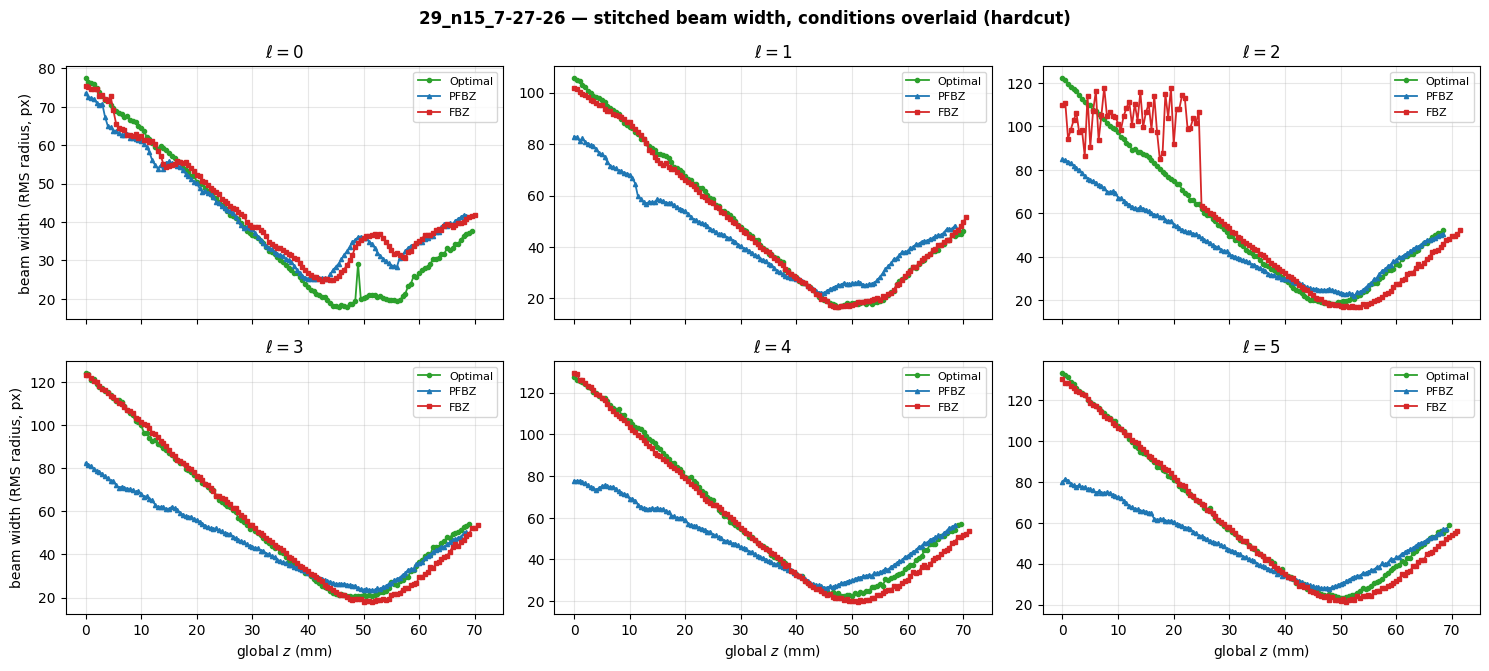

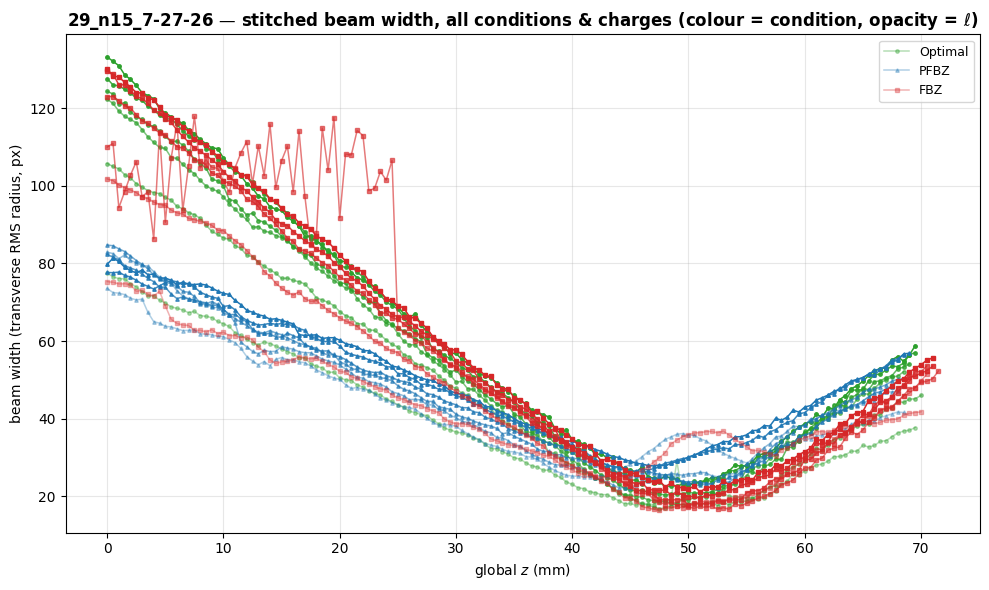

saved condition-overlay width plots to outputs/waterfalls_stitched_full


In [40]:
COND_STYLE = {
    "Optimal": {"color": "C2", "marker": "o", "ls": "-"},
    "PFBZ":    {"color": "C0", "marker": "^", "ls": "-"},
    "FBZ":     {"color": "C3", "marker": "s", "ls": "-"},
}
COND_ORDER = ["Optimal", "PFBZ", "FBZ"]   # legend / draw order


def width_curve(cond: str, ell: int):
    st = stitched[cond][ell][CHOSEN_BLEND]
    return st.z_mm, stitched_width(st)


# --- one panel per ell, conditions overlaid --------------------------------
all_ells = sorted({ell for cond in CONDITION_SEGMENTS for ell in data[cond]})
ncol = 3
nrow = int(np.ceil(len(all_ells) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.0 * ncol, 3.4 * nrow),
                         sharex=True, squeeze=False)
for ell, ax in zip(all_ells, axes.ravel()):
    for cond in COND_ORDER:
        if ell not in data.get(cond, {}):
            continue
        z, w = width_curve(cond, ell)
        s = COND_STYLE[cond]
        ax.plot(z, w, marker=s["marker"], ls=s["ls"], ms=3, lw=1.3,
                color=s["color"], label=cond)
    ax.set_title(f"$\\ell={ell}$")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
for ax in axes.ravel()[len(all_ells):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("beam width (RMS radius, px)")
for ax in axes[-1, :]:
    ax.set_xlabel("global $z$ (mm)")
fig.suptitle(f"{RUN} — stitched beam width, conditions overlaid ({CHOSEN_BLEND})",
             fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_ROOT / f"{RUN}_width_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# --- single combined panel: every condition and charge ---------------------
fig, ax = plt.subplots(figsize=(10, 6))
ell_alpha = {ell: a for ell, a in zip(all_ells, np.linspace(0.35, 1.0, len(all_ells)))}
for cond in COND_ORDER:
    if cond not in data:
        continue
    s = COND_STYLE[cond]
    for ell in data[cond]:
        z, w = width_curve(cond, ell)
        ax.plot(z, w, marker=s["marker"], ls=s["ls"], ms=2.5, lw=1.1,
                color=s["color"], alpha=ell_alpha[ell],
                label=cond if ell == list(data[cond])[0] else None)
    # legend proxy already added on first ell
ax.set_xlabel("global $z$ (mm)")
ax.set_ylabel("beam width (transverse RMS radius, px)")
ax.set_title(f"{RUN} — stitched beam width, all conditions & charges "
             f"(colour = condition, opacity = $\\ell$)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_ROOT / f"{RUN}_width_by_condition_combined.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved condition-overlay width plots to {OUT_ROOT.relative_to(REPO_ROOT)}")

## Centroid diagnostic across the stitched scan

Per condition: the base notebook's centroid figure on the global $z$ grid, seams dashed. A
discontinuity at a seam means the two segments' beams sit at different sensor positions — harmless for
the centred waterfall, but worth seeing. The bottom panel shows **segment coverage** (1 = single
segment, 2 = inside an overlap, 0 = a gap).

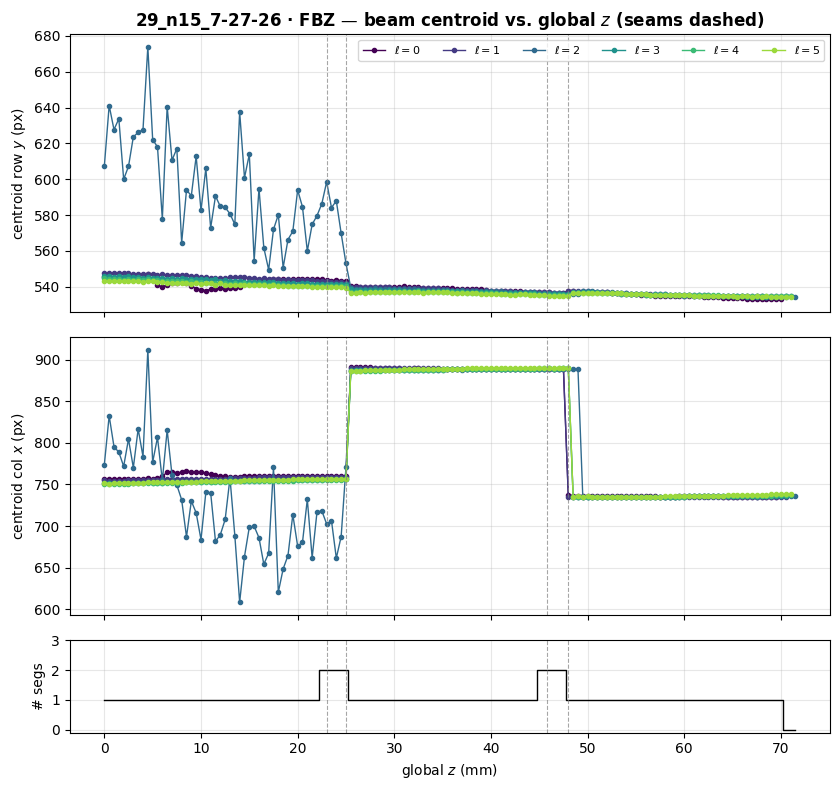

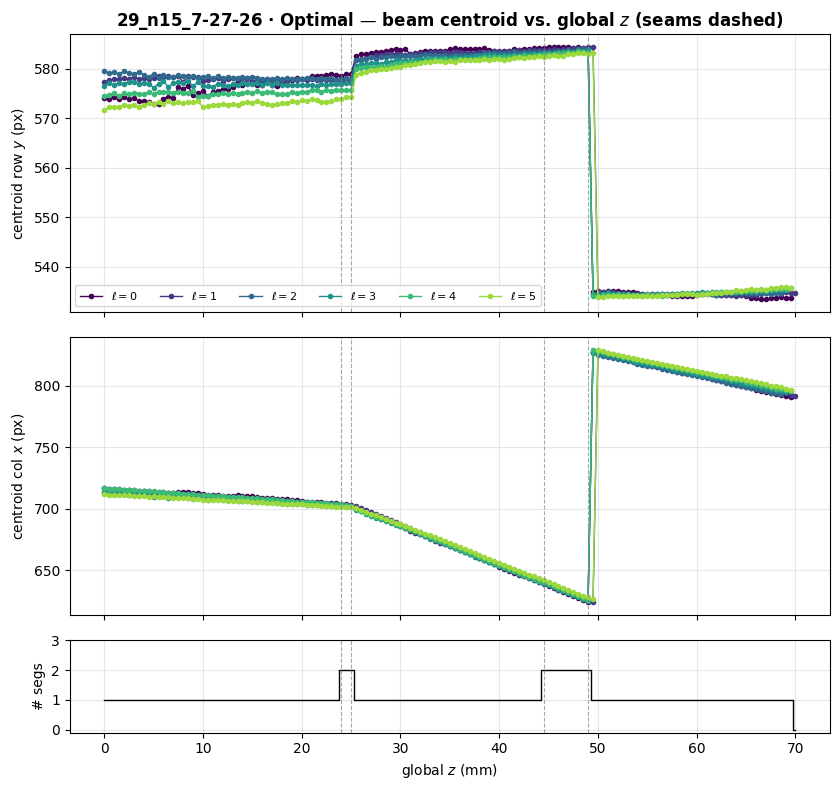

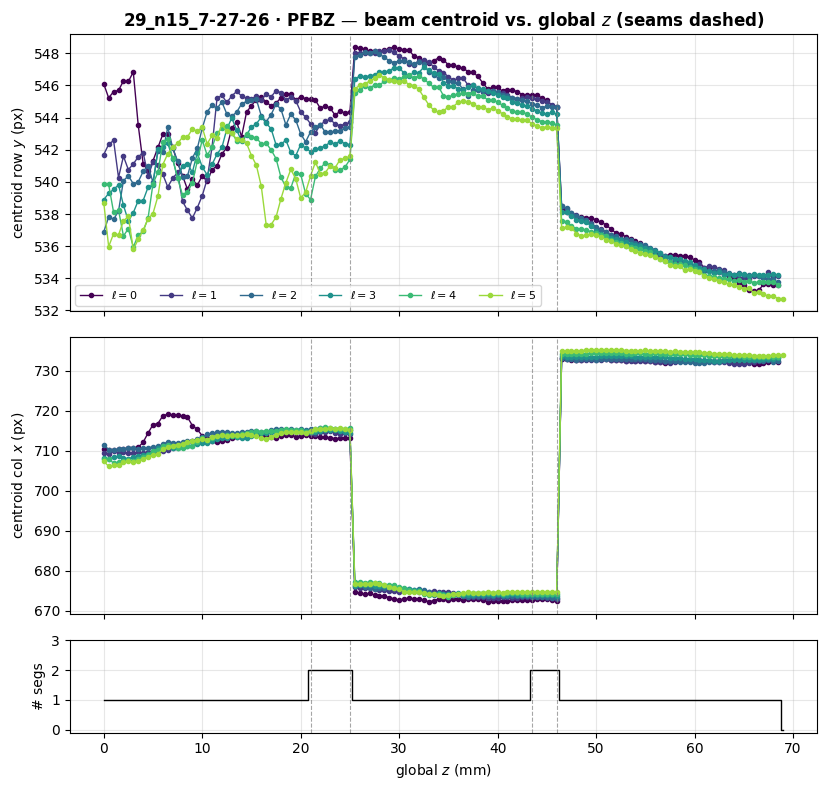

In [41]:
def plot_centroids(cond: str):
    ells = list(data[cond])
    colours = plt.get_cmap("viridis")(np.linspace(0, 0.85, len(ells)))
    fig, axes = plt.subplots(3, 1, figsize=(8.5, 8), sharex=True,
                             gridspec_kw={"height_ratios": [3, 3, 1]})
    for ell, colour in zip(ells, colours):
        st = stitched[cond][ell][CHOSEN_BLEND]
        axes[0].plot(st.z_mm, st.centroid_y, "o-", ms=3, lw=1, color=colour, label=f"$\\ell={ell}$")
        axes[1].plot(st.z_mm, st.centroid_x, "o-", ms=3, lw=1, color=colour)
    ref_ell = ells[0]
    axes[2].step(stitched[cond][ref_ell][CHOSEN_BLEND].z_mm,
                 stitched[cond][ref_ell][CHOSEN_BLEND].coverage, where="mid", color="k", lw=1)
    axes[2].set_ylabel("# segs")
    axes[2].set_yticks([0, 1, 2, 3])
    for ax in axes:
        for lo, hi in SEAM_BANDS[cond]:
            for y in (lo, hi):
                ax.axvline(y, color="grey", ls="--", lw=0.8, alpha=0.7)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("centroid row $y$ (px)")
    axes[0].set_title(f"{RUN} · {cond} — beam centroid vs. global $z$ (seams dashed)",
                      fontweight="bold")
    axes[0].legend(ncol=len(ells), fontsize=8)
    axes[1].set_ylabel("centroid col $x$ (px)")
    axes[2].set_xlabel("global $z$ (mm)")
    fig.tight_layout()
    fig.savefig(cond_out(cond) / f"{cond}_centroids.png", dpi=150)
    plt.show()
    plt.close(fig)


for cond in CONDITION_SEGMENTS:
    plot_centroids(cond)

## Summary table

One row per condition / $\ell$ for the chosen blend: the stitched $z$ span, the brightest-frame $z$,
and the hand-set global start applied to each segment. Written to
`outputs/waterfalls_stitched_full/<RUN>_summary.csv`.

In [42]:
rows = []
for cond in CONDITION_SEGMENTS:
    for ell in data[cond]:
        st = stitched[cond][ell][CHOSEN_BLEND]
        row = {
            "run": RUN, "condition": cond, "ell": ell, "blend": CHOSEN_BLEND,
            "n_frames": st.z_mm.size,
            "z_min_mm": st.z_mm.min(), "z_max_mm": st.z_mm.max(),
            "brightest_z_mm": st.brightest_z,
        }
        for seg in CONDITION_SEGMENTS[cond]:
            row[f"start_{seg}_mm"] = (round(STARTS_MM[cond][ell][seg], 2)
                                      if seg in STARTS_MM[cond][ell] else np.nan)
        rows.append(row)

summary = pd.DataFrame(rows).round(2)
summary.to_csv(OUT_ROOT / f"{RUN}_summary.csv", index=False)
with pd.option_context("display.max_rows", None, "display.width", 200):
    display(summary)
print(f"\nsaved {RUN}_summary.csv to {OUT_ROOT.relative_to(REPO_ROOT)}")

,run,condition,ell,blend,n_frames,z_min_mm,z_max_mm,brightest_z_mm,start_0mm-25mm_mm,start_20mm-45mm_mm,start_40mm-65mm_mm
0,29_n15_7-27-26,FBZ,0,hardcut,144,0.0,71.5,43.5,0.0,22.5,45.0
1,29_n15_7-27-26,FBZ,1,hardcut,144,0.0,71.5,46.0,0.0,22.5,45.5
2,29_n15_7-27-26,FBZ,2,hardcut,144,0.0,71.5,49.0,0.0,24.0,46.5
3,29_n15_7-27-26,FBZ,3,hardcut,144,0.0,71.5,50.5,0.0,23.0,45.5
4,29_n15_7-27-26,FBZ,4,hardcut,144,0.0,71.5,51.0,0.0,23.0,46.0
5,29_n15_7-27-26,FBZ,5,hardcut,144,0.0,71.5,51.0,0.0,23.0,46.0
6,29_n15_7-27-26,Optimal,0,hardcut,141,0.0,70.0,43.5,0.0,24.0,44.5
7,29_n15_7-27-26,Optimal,1,hardcut,141,0.0,70.0,47.5,0.0,24.5,45.0
8,29_n15_7-27-26,Optimal,2,hardcut,141,0.0,70.0,50.0,0.0,24.0,43.5
9,29_n15_7-27-26,Optimal,3,hardcut,141,0.0,70.0,49.5,0.0,24.0,44.0



saved 29_n15_7-27-26_summary.csv to outputs/waterfalls_stitched_full
